In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pushd "/content/drive/MyDrive/Disadvantage Males/"

/content/drive/MyDrive/Disadvantage Males


['/content']

In [ ]:
!pip install geojson
!pip install geodatasets
!pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.0 MB/s eta 0:00:00


In [ ]:
#Import libraries and find some data
import pandas as pd
import geojson as gpd
import geopandas as gp
import matplotlib.pyplot as plt
import mapclassify
import geopandas
import geodatasets
from geodatasets import get_path

In [ ]:
from geodatasets import get_path


#Download Counties Shapefiles

In [ ]:
counties = geopandas.read_file("cb_2023_us_county_500k/cb_2023_us_county_500k.shp") #Create a dataframe for analysis

In [ ]:
counties['COUNTY_FIPS'] = counties['STATEFP'] + counties['COUNTYFP']
counties['COUNTY_FIPS'] = counties['COUNTY_FIPS'].astype(str)
cols = list(counties.columns)
cols.insert(2, cols.pop(cols.index('COUNTY_FIPS')))
counties = counties.loc[:, cols]
counties.head()


,STATEFP,COUNTYFP,COUNTY_FIPS,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,01,003,01003,00161527,0500000US01003,01003,Baldwin,Baldwin County,AL,Alabama,06,4117725048,1132887203,"POLYGON ((-88.02858 30.22676, -88.02399 30.230..."
1,01,069,01069,00161560,0500000US01069,01069,Houston,Houston County,AL,Alabama,06,1501742235,4795415,"POLYGON ((-85.71209 31.19727, -85.70934 31.198..."
2,01,005,01005,00161528,0500000US01005,01005,Barbour,Barbour County,AL,Alabama,06,2292160151,50523213,"POLYGON ((-85.74803 31.61918, -85.74544 31.618..."
3,01,119,01119,00161585,0500000US01119,01119,Sumter,Sumter County,AL,Alabama,06,2340898915,24634880,"POLYGON ((-88.41492 32.36452, -88.41471 32.366..."
4,05,091,05091,00069166,0500000US05091,05091,Miller,Miller County,AR,Arkansas,06,1616257232,36848741,"POLYGON ((-94.04343 33.55158, -94.04332 33.552..."


<Axes: >

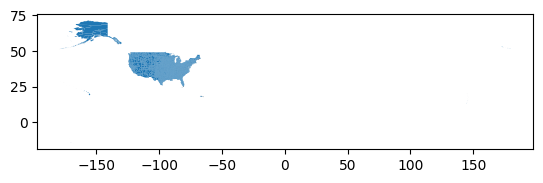

In [ ]:
counties.plot()

#Downloading Disadvantage Variables

In [ ]:
acs_counties = pd.read_csv("acs_counties_analysis_file.csv", dtype={'YEAR' : str,'STATE': str, 'COUNTY': str})

In [ ]:
acs_counties = acs_counties.drop(columns= 'Unnamed: 0')

acs_counties['COUNTY_FIPS'] = acs_counties['COUNTY'].astype(str)
col = acs_counties.pop('COUNTY_FIPS')
acs_counties.insert(3, 'COUNTY_FIPS', col)
acs_counties.head()

,YEAR,STATE,COUNTY,COUNTY_FIPS,male_25_64_tot,male_2564_less_ba,male_2564_less_ba_pct,pop_county_male_2554,pop_opm_county_male_2554,opm_male_2554,pop_county_male_mar_2554,pop_county_male_never_mar_2554,pop_county_male_separated_2554,pop_county_male_other_2554,pop_county_male_widowed_2554,pop_county_male_divorced_2554,male_marriage_rate_2554
0,2015,01,01001,01001,13977,10443,0.747156,10896.0,879.0,0.080672,7100,1865,242,258,23,1511,0.645513
1,2015,01,01003,01003,49230,36731,0.746110,35475.0,4042.0,0.113939,20055,8878,1147,1559,180,4642,0.550040
2,2015,01,01005,01005,8235,7494,0.910018,4415.0,828.0,0.187542,1930,2696,277,555,34,1019,0.296421
3,2015,01,01007,01007,6955,6339,0.911431,4218.0,291.0,0.068990,2490,1698,151,346,117,807,0.443929
4,2015,01,01009,01009,14939,13275,0.888614,11265.0,1452.0,0.128895,6901,1809,331,741,50,1516,0.608125


In [ ]:
acs_counties.dtypes

,0
YEAR,object
STATE,object
COUNTY,object
COUNTY_FIPS,object
male_25_64_tot,int64
male_2564_less_ba,int64
male_2564_less_ba_pct,float64
pop_county_male_2554,float64
pop_opm_county_male_2554,float64
opm_male_2554,float64


In [ ]:
acs_counties['perc_never_married'] = acs_counties['pop_county_male_never_mar_2554'] / (acs_counties['pop_county_male_never_mar_2554'] +
                                                                                       acs_counties['pop_county_male_mar_2554']+
                                                                                       acs_counties['pop_county_male_divorced_2554'] +
                                                                                       acs_counties['pop_county_male_separated_2554']+
                                                                                       acs_counties['pop_county_male_widowed_2554']+
                                                                                       acs_counties['pop_county_male_other_2554'])



In [ ]:
acs_counties.columns

Index(['YEAR', 'STATE', 'COUNTY', 'COUNTY_FIPS', 'male_25_64_tot',
       'male_2564_less_ba', 'male_2564_less_ba_pct', 'pop_county_male_2554',
       'pop_opm_county_male_2554', 'opm_male_2554', 'pop_county_male_mar_2554',
       'pop_county_male_never_mar_2554', 'pop_county_male_separated_2554',
       'pop_county_male_other_2554', 'pop_county_male_widowed_2554',
       'pop_county_male_divorced_2554', 'male_marriage_rate_2554',
       'perc_never_married'],
      dtype='object')

In [ ]:
# Pivot wider by year
#acs_counties['YEAR'] = acs_counties['YEAR'].astype(str)

acs_counties_pivot = acs_counties.pivot(index=['COUNTY_FIPS', 'STATE', 'COUNTY'], columns='YEAR', values=acs_counties.columns[4:18])

# Reset the index to make 'COUNTY_FIPS' a regular column
acs_counties_pivot = acs_counties_pivot.reset_index()

acs_counties_pivot.head()

COUNTY_FIPS STATE COUNTY male_25_64_tot                             \
YEAR                                    2015     2016     2017     2018   
0          01001    01  01001        13977.0  13898.0  13984.0  14101.0   
1          01003    01  01003        49230.0  49640.0  50565.0  51414.0   
2          01005    01  01005         8235.0   7881.0   7909.0   7687.0   
3          01007    01  01007         6955.0   7023.0   7047.0   6808.0   
4          01009    01  01009        14939.0  14789.0  14730.0  14615.0   

                                 ... male_marriage_rate_2554            \
YEAR     2019     2021     2022  ...                    2019      2021   
0     14086.0  15065.0  15250.0  ...                0.616087  0.592739   
1     52429.0  55726.0  57268.0  ...                0.548110  0.564199   
2      7535.0   7488.0   7099.0  ...                0.297119  0.283442   
3      7087.0   7236.0   6864.0  ...                0.361200  0.381940   
4     14664.0  15188.0  15334.0  ...                0.598711  0.569839   

               perc_never_married                                          \
YEAR      2022               2015      2016      2017      2018      2019   
0     0.606745           0.169561  0.167468  0.169722  0.178697  0.229751   
1     0.605011           0.243493  0.245472  0.260098  0.260449  0.255233   
2     0.256204           0.414068  0.398126  0.417203  0.418508  0.426949   
3     0.392186           0.302728  0.318887  0.344145  0.357866  0.384629   
4     0.563240           0.159411  0.156233  0.167812  0.170738  0.195950   

                          
YEAR      2021      2022  
0     0.228376  0.218319  
1     0.260567  0.233137  
2     0.489737  0.504015  
3     0.406184  0.393860  
4     0.260449  0.263991  

[5 rows x 101 columns]

In [ ]:
# Rename columns by pasting together index
acs_counties_pivot.columns = [''.join(col).strip() for col in acs_counties_pivot.columns.values]
acs_counties_pivot


,COUNTY_FIPS,STATE,COUNTY,male_25_64_tot2015,male_25_64_tot2016,male_25_64_tot2017,male_25_64_tot2018,male_25_64_tot2019,male_25_64_tot2021,male_25_64_tot2022,...,male_marriage_rate_25542019,male_marriage_rate_25542021,male_marriage_rate_25542022,perc_never_married2015,perc_never_married2016,perc_never_married2017,perc_never_married2018,perc_never_married2019,perc_never_married2021,perc_never_married2022
0,01001,01,01001,13977.0,13898.0,13984.0,14101.0,14086.0,15065.0,15250.0,...,0.616087,0.592739,0.606745,0.169561,0.167468,0.169722,0.178697,0.229751,0.228376,0.218319
1,01003,01,01003,49230.0,49640.0,50565.0,51414.0,52429.0,55726.0,57268.0,...,0.548110,0.564199,0.605011,0.243493,0.245472,0.260098,0.260449,0.255233,0.260567,0.233137
2,01005,01,01005,8235.0,7881.0,7909.0,7687.0,7535.0,7488.0,7099.0,...,0.297119,0.283442,0.256204,0.414068,0.398126,0.417203,0.418508,0.426949,0.489737,0.504015
3,01007,01,01007,6955.0,7023.0,7047.0,6808.0,7087.0,7236.0,6864.0,...,0.361200,0.381940,0.392186,0.302728,0.318887,0.344145,0.357866,0.384629,0.406184,0.393860
4,01009,01,01009,14939.0,14789.0,14730.0,14615.0,14664.0,15188.0,15334.0,...,0.598711,0.569839,0.563240,0.159411,0.156233,0.167812,0.170738,0.195950,0.260449,0.263991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3148,56037,56,56037,12825.0,12703.0,12476.0,12363.0,12060.0,11611.0,11549.0,...,0.565636,0.548934,0.563830,0.209110,0.205267,0.241093,0.271172,0.232635,0.274467,0.267559
3149,56039,56,56039,7589.0,7491.0,7540.0,7323.0,7308.0,7370.0,7359.0,...,0.455598,0.459078,0.470245,0.494685,0.458208,0.452612,0.401002,0.405840,0.423005,0.431572
3150,56041,56,56041,5297.0,5207.0,5224.0,5205.0,5167.0,5188.0,5144.0,...,0.705055,0.628557,0.605659,0.179619,0.164803,0.186854,0.177198,0.171398,0.194205,0.219626
3151,56043,56,56043,2120.0,2132.0,2047.0,2031.0,1966.0,1845.0,1842.0,...,0.531227,0.598756,0.605243,0.152291,0.207861,0.219341,0.248551,0.271859,0.252722,0.212734


#Joining Geography with Response Variables

In [ ]:
man_counties = counties.merge(acs_counties_pivot, how='left', left_on='COUNTY_FIPS', right_on='COUNTY_FIPS') #merge the dataframes to get the population and the geometry
man_counties.head()

,STATEFP,COUNTYFP,COUNTY_FIPS,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,...,male_marriage_rate_25542019,male_marriage_rate_25542021,male_marriage_rate_25542022,perc_never_married2015,perc_never_married2016,perc_never_married2017,perc_never_married2018,perc_never_married2019,perc_never_married2021,perc_never_married2022
0,01,003,01003,00161527,0500000US01003,01003,Baldwin,Baldwin County,AL,Alabama,...,0.548110,0.564199,0.605011,0.243493,0.245472,0.260098,0.260449,0.255233,0.260567,0.233137
1,01,069,01069,00161560,0500000US01069,01069,Houston,Houston County,AL,Alabama,...,0.463902,0.493178,0.495279,0.305055,0.325633,0.321552,0.327262,0.329566,0.318327,0.316748
2,01,005,01005,00161528,0500000US01005,01005,Barbour,Barbour County,AL,Alabama,...,0.297119,0.283442,0.256204,0.414068,0.398126,0.417203,0.418508,0.426949,0.489737,0.504015
3,01,119,01119,00161585,0500000US01119,01119,Sumter,Sumter County,AL,Alabama,...,0.356015,0.365611,0.437817,0.415820,0.469607,0.432255,0.409329,0.458688,0.455618,0.430838
4,05,091,05091,00069166,0500000US05091,05091,Miller,Miller County,AR,Arkansas,...,0.427560,0.407461,0.376915,0.241204,0.267506,0.275740,0.314102,0.349898,0.305869,0.325507


In [ ]:
man_counties['geometry'] = man_counties.geometry

In [ ]:
names = man_counties.columns.tolist()
print(names)

['STATEFP', 'COUNTYFP', 'COUNTY_FIPS', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry', 'STATE', 'COUNTY', 'male_25_64_tot2015', 'male_25_64_tot2016', 'male_25_64_tot2017', 'male_25_64_tot2018', 'male_25_64_tot2019', 'male_25_64_tot2021', 'male_25_64_tot2022', 'male_2564_less_ba2015', 'male_2564_less_ba2016', 'male_2564_less_ba2017', 'male_2564_less_ba2018', 'male_2564_less_ba2019', 'male_2564_less_ba2021', 'male_2564_less_ba2022', 'male_2564_less_ba_pct2015', 'male_2564_less_ba_pct2016', 'male_2564_less_ba_pct2017', 'male_2564_less_ba_pct2018', 'male_2564_less_ba_pct2019', 'male_2564_less_ba_pct2021', 'male_2564_less_ba_pct2022', 'pop_county_male_25542015', 'pop_county_male_25542016', 'pop_county_male_25542017', 'pop_county_male_25542018', 'pop_county_male_25542019', 'pop_county_male_25542021', 'pop_county_male_25542022', 'pop_opm_county_male_25542015', 'pop_opm_county_male_25542016', 'pop_opm_county_male_25542017', 'po

In [ ]:
man_counties['STATE_INT'] = man_counties['STATEFP'].astype(int)


##City Labels

In [ ]:
# prompt: add major city labels

import matplotlib.pyplot as plt

# Assuming 'man_counties' and 'males_state_agg_pivot' are already defined and plotted as in your code.

# Add major city labels to the plots.  You'll need to define the city locations.
# Example city data (replace with your actual city data)
city_locations = {
    'New York': (-74.0060, 40.7128),  # Longitude, Latitude
    'Los Angeles': (-118.2437, 34.0522),
    'Chicago': (-87.6298, 41.8781),
    'Houston': (-95.3698, 29.7604),
    'Phoenix': (-112.0740, 33.4484),
    'Philadelphia': (-75.1652, 39.9526),
    'San Antonio': (-98.4936, 29.4241),
    'San Diego': (-117.1611, 32.7157),
    'Dallas': (-96.7970, 32.7767),
    'San Jose': (-121.8863,37.3382),
    'Austin': (-97.7431, 30.2672),
    'Jacksonville': (-81.6557, 30.3322),
    'Washington': (-77.0369, 38.9072),
    'El Paso': (-106.4813, 31.7),
    'Denver': (-104.9903, 39.7392),
    'Park City': (-111.4980, 40.6461),
    'Detroit': (-83.0458, 42.3314),
    'Seattle': (-122.3321, 47.6062),
    'Memphis': (-89.3985, 35.1936)
}



def add_city_labels(ax, city_locations, x_col='INTPTLON', y_col='INTPTLAT'):
  for city, (lon, lat) in city_locations.items():
    ax.text(lon, lat, city, fontsize=8, ha='center', va='bottom', color='black')




#Mapping County Level

<ipython-input-21-aaf87df12fa4>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


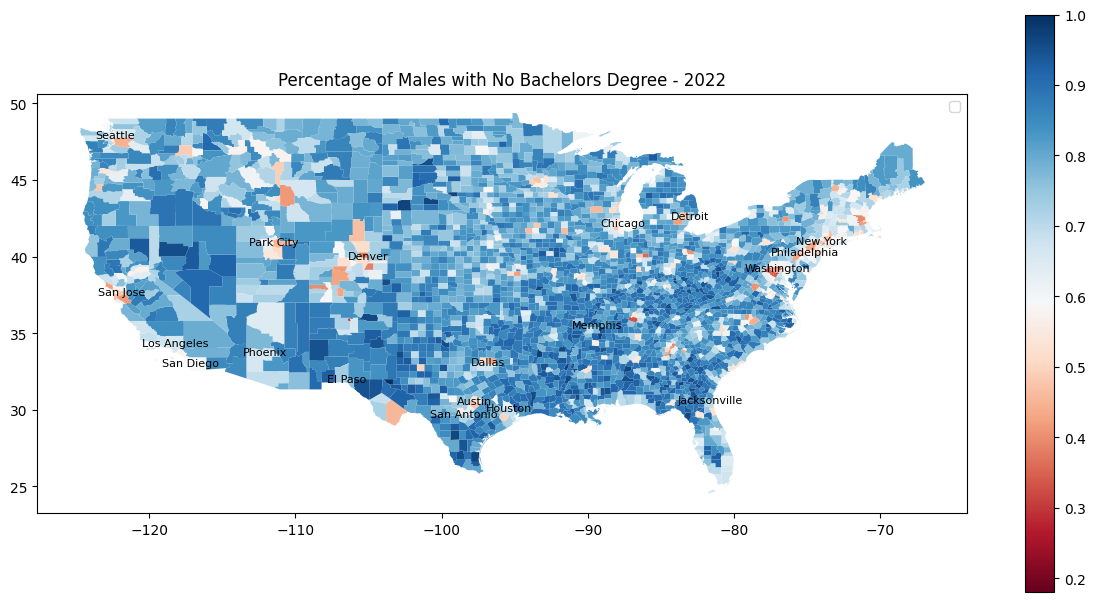

In [ ]:
man_counties[(man_counties['STATE_NAME'] != 'Alaska') & (man_counties['STATE_NAME'] != 'Hawaii')].plot('male_2564_less_ba_pct2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels
plt.legend()
plt.title("Percentage of Males with No Bachelors Degree - 2022")  # Add a title
plt.show()

<ipython-input-22-28709bacfa2f>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


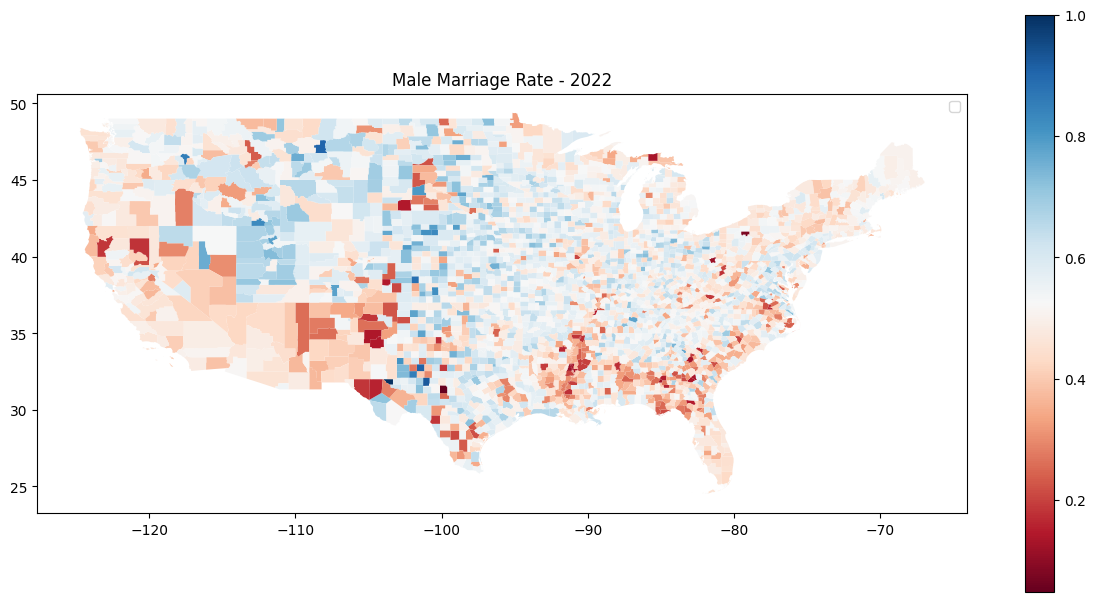

In [ ]:
man_counties[(man_counties['STATE_NAME'] != 'Alaska') & (man_counties['STATE_NAME'] != 'Hawaii')].plot('male_marriage_rate_25542022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
plt.legend()
plt.title("Male Marriage Rate - 2022")  # Add a title
plt.show()

<ipython-input-23-2f798f02531d>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


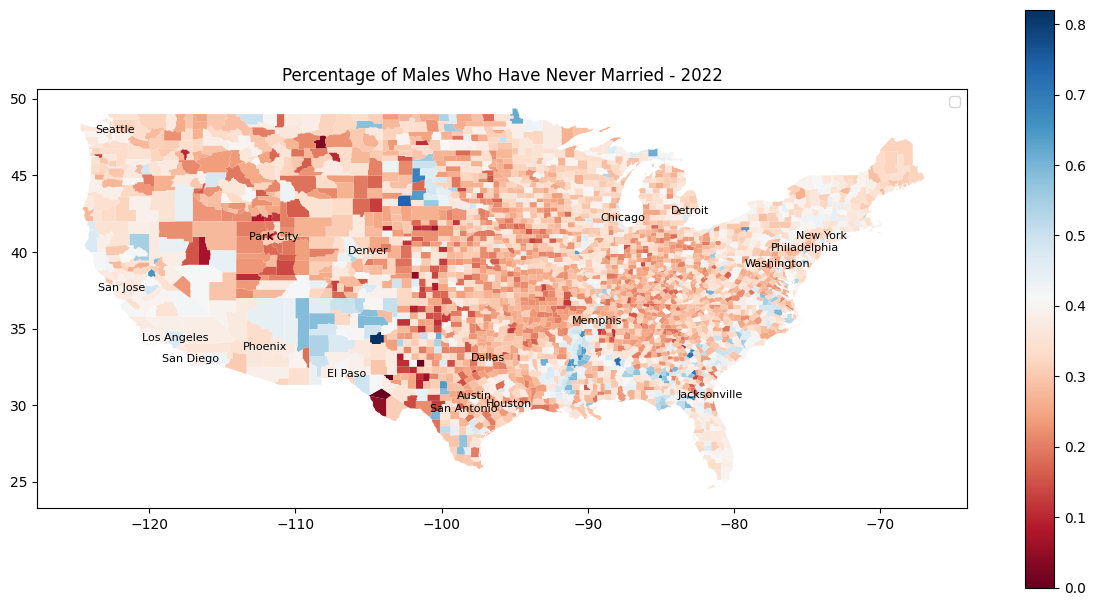

In [ ]:
man_counties[(man_counties['STATE_NAME'] != 'Alaska') & (man_counties['STATE_NAME'] != 'Hawaii')].plot('perc_never_married2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed

plt.legend()
add_city_labels(plt, city_locations) # Add city labels

plt.title("Percentage of Males Who Have Never Married - 2022")  # Add a title
plt.show()


<ipython-input-24-6cc765c87bc0>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


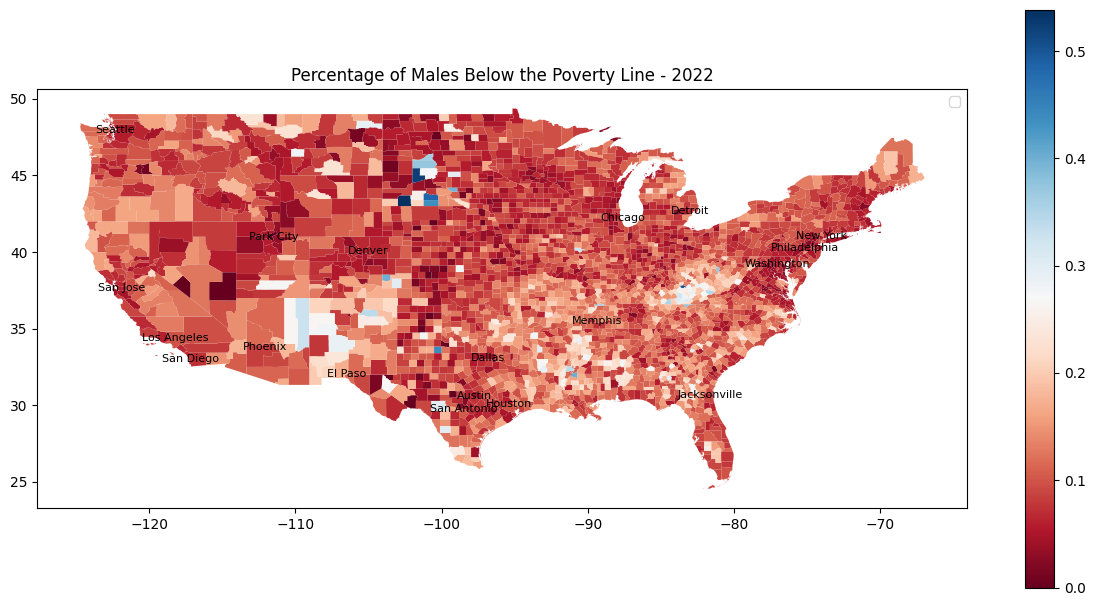

In [ ]:
man_counties[(man_counties['STATE_NAME'] != 'Alaska') & (man_counties['STATE_NAME'] != 'Hawaii')].plot('opm_male_25542022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels

plt.legend()
plt.title("Percentage of Males Below the Poverty Line - 2022")  # Add a title
plt.show()

#Histograms

Text(0.5, 1.0, 'Percentage of Males with No Bachelors Degree - 2022')

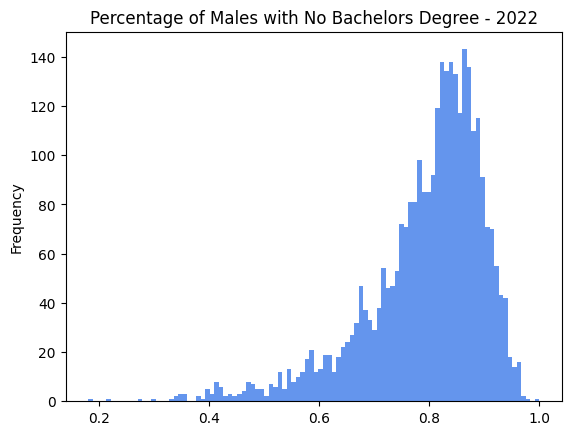

In [ ]:
man_counties['male_2564_less_ba_pct2022'].plot.hist(bins=100, color = "cornflowerblue")

plt.title("Percentage of Males with No Bachelors Degree - 2022")

Text(0.5, 1.0, 'Male Marriage Rate - 2022')

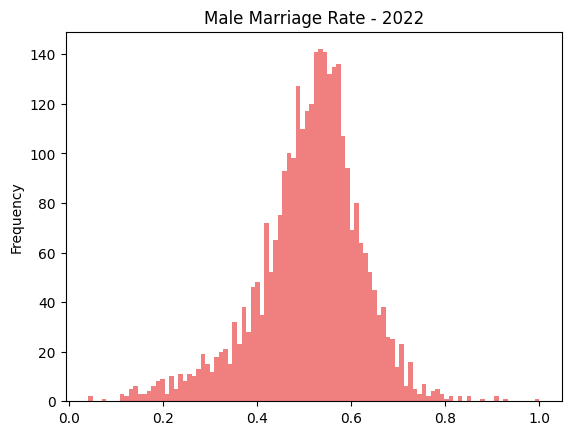

In [ ]:
man_counties['male_marriage_rate_25542022'].plot.hist(bins=100, color = "lightcoral")

plt.title("Male Marriage Rate - 2022")

Text(0.5, 1.0, 'Percentage of Males Below the Poverty Line - 2022')

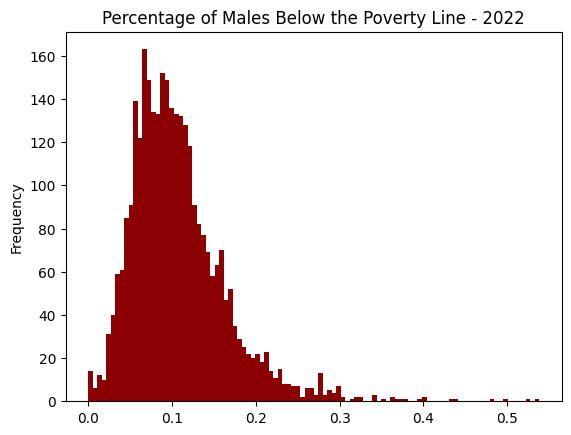

In [ ]:
man_counties['opm_male_25542022'].plot.hist(bins=100, color = "darkred")

plt.title("Percentage of Males Below the Poverty Line - 2022")

#import state aggregates

In [ ]:

males_state_agg = pd.read_csv('males_state_agg.csv', dtype={'STATE': str})  # Replace with your file's name
males_state_agg_pivot = pd.read_csv('males_state_agg_pivot.csv', dtype={'STATE': str})  # Replace with your file's name



In [ ]:
males_state_agg_pivot = counties.merge(males_state_agg_pivot, how='left', left_on='STATEFP', right_on='STATE') #merge the dataframes to get the population and the geometry


In [ ]:
names = males_state_agg_pivot.columns.tolist()
print(names)
males_state_agg_pivot.head()

['STATEFP', 'COUNTYFP', 'COUNTY_FIPS', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry', 'STATE', 'male_25_64_total_2015', 'male_25_64_total_2016', 'male_25_64_total_2017', 'male_25_64_total_2018', 'male_25_64_total_2019', 'male_25_64_total_2021', 'male_25_64_total_2022', 'male_2564_less_ba_2015', 'male_2564_less_ba_2016', 'male_2564_less_ba_2017', 'male_2564_less_ba_2018', 'male_2564_less_ba_2019', 'male_2564_less_ba_2021', 'male_2564_less_ba_2022', 'male_2564_less_ba_pct_2015', 'male_2564_less_ba_pct_2016', 'male_2564_less_ba_pct_2017', 'male_2564_less_ba_pct_2018', 'male_2564_less_ba_pct_2019', 'male_2564_less_ba_pct_2021', 'male_2564_less_ba_pct_2022', 'pop_county_male_2554_2015', 'pop_county_male_2554_2016', 'pop_county_male_2554_2017', 'pop_county_male_2554_2018', 'pop_county_male_2554_2019', 'pop_county_male_2554_2021', 'pop_county_male_2554_2022', 'pop_opm_county_male_2554_2015', 'pop_opm_county_male_2554_2016', '

,STATEFP,COUNTYFP,COUNTY_FIPS,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,...,male_marriage_rate_2554_2019,male_marriage_rate_2554_2021,male_marriage_rate_2554_2022,perc_never_married_2015,perc_never_married_2016,perc_never_married_2017,perc_never_married_2018,perc_never_married_2019,perc_never_married_2021,perc_never_married_2022
0,01,003,01003,00161527,0500000US01003,01003,Baldwin,Baldwin County,AL,Alabama,...,0.507282,0.496334,0.503159,0.276630,0.284402,0.291713,0.298269,0.306778,0.321758,0.319736
1,01,069,01069,00161560,0500000US01069,01069,Houston,Houston County,AL,Alabama,...,0.507282,0.496334,0.503159,0.276630,0.284402,0.291713,0.298269,0.306778,0.321758,0.319736
2,01,005,01005,00161528,0500000US01005,01005,Barbour,Barbour County,AL,Alabama,...,0.507282,0.496334,0.503159,0.276630,0.284402,0.291713,0.298269,0.306778,0.321758,0.319736
3,01,119,01119,00161585,0500000US01119,01119,Sumter,Sumter County,AL,Alabama,...,0.507282,0.496334,0.503159,0.276630,0.284402,0.291713,0.298269,0.306778,0.321758,0.319736
4,05,091,05091,00069166,0500000US05091,05091,Miller,Miller County,AR,Arkansas,...,0.534381,0.525853,0.529185,0.248021,0.253451,0.255353,0.261663,0.264294,0.278928,0.284101


In [ ]:
names = males_state_agg.columns.tolist()
print(names)



['STATE', 'YEAR', 'male_25_64_total', 'male_2564_less_ba', 'male_2564_less_ba_pct', 'pop_county_male_2554', 'pop_opm_county_male_2554', 'opm_male_2554', 'pop_county_male_mar_2554', 'pop_county_male_never_mar_2554', 'pop_county_male_separated_2554', 'pop_county_male_other_2554', 'pop_county_male_widowed_2554', 'pop_county_male_divorced_2554', 'male_marriage_rate_2554', 'perc_never_married']


#Mapping State Level

<ipython-input-32-5d91ee050b8d>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


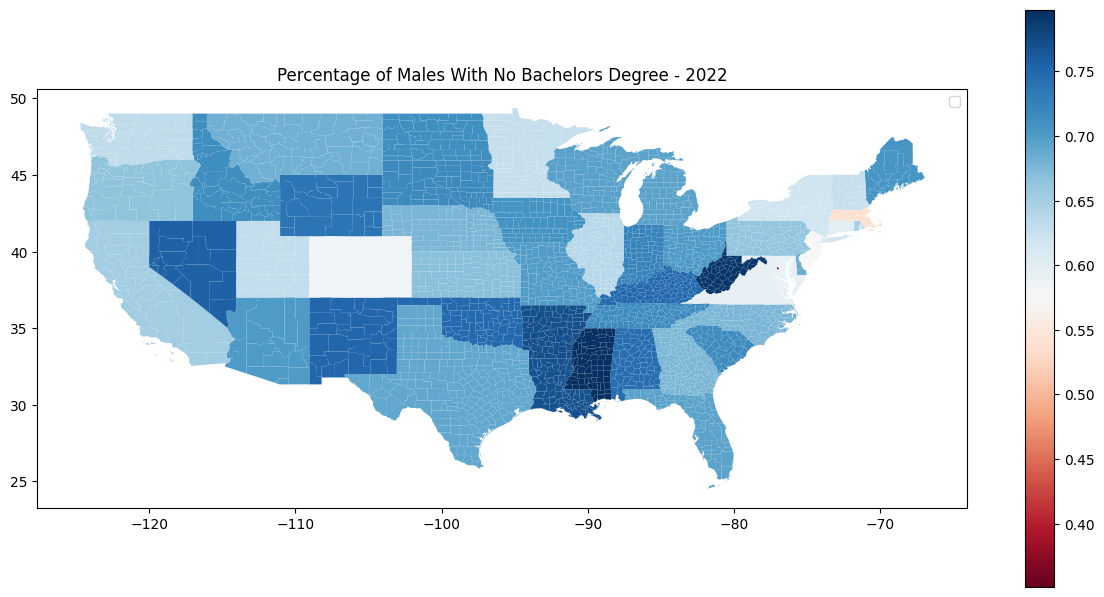

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('male_2564_less_ba_pct_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
plt.legend()
plt.title("Percentage of Males With No Bachelors Degree - 2022")  # Add a title
plt.show()

<ipython-input-33-b97ef5deffa5>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


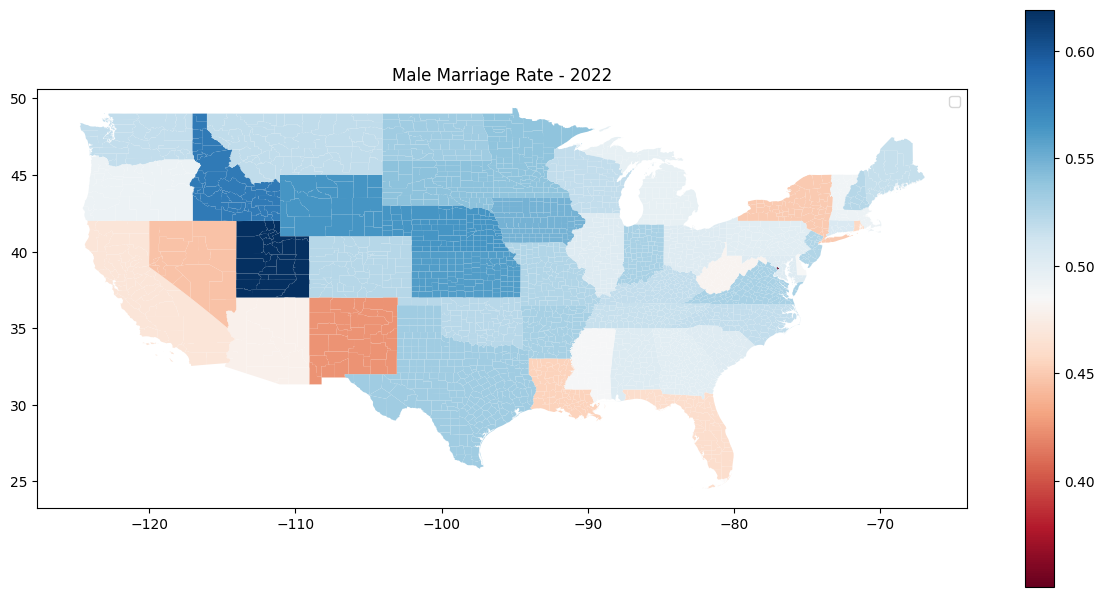

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('male_marriage_rate_2554_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
plt.legend()
plt.title("Male Marriage Rate - 2022")  # Add a title
plt.show()

<ipython-input-34-ce989bf43314>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


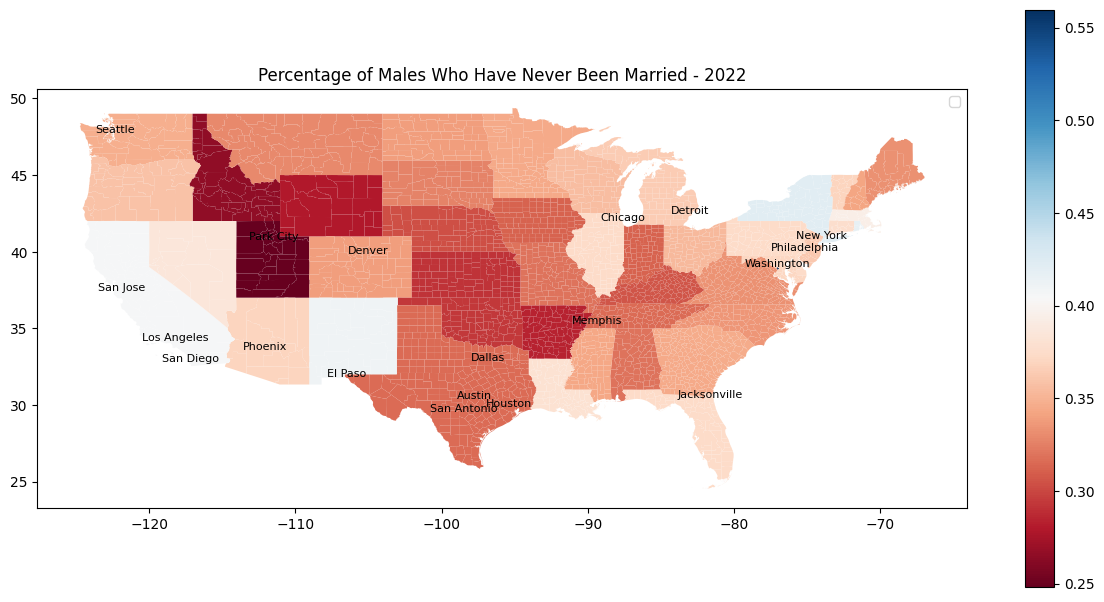

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('perc_never_married_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels

plt.legend()
plt.title("Percentage of Males Who Have Never Been Married - 2022")  # Add a title
plt.show()

<ipython-input-35-e7b454c58f08>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


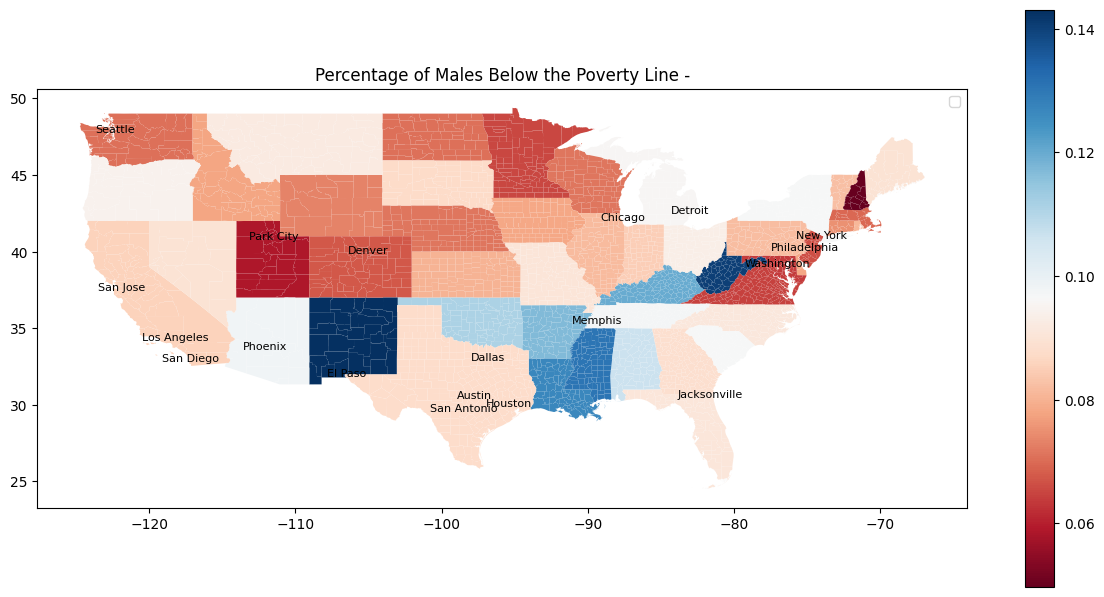

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('opm_male_2554_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels
plt.legend()
plt.title("Percentage of Males Below the Poverty Line -")  # Add a title
plt.show()

##Mapping State Density

In [ ]:
vars


<function vars>

In [ ]:
state_disadvanted_totals_2022 = acs_counties[ acs_counties['YEAR'] == '2022'].groupby('STATE')[['male_2564_less_ba', 'pop_opm_county_male_2554', 'pop_county_male_mar_2554']].sum()
state_disadvanted_totals_2022.head()

,male_2564_less_ba,pop_opm_county_male_2554,pop_county_male_mar_2554
STATE,,,
01,933293,95914.0,467675
02,154576,12577.0,75116
04,1271750,130294.0,667150
05,581175,62707.0,299466
06,6963524,696184.0,3874411


In [ ]:
us_disadvantaged_totals_2022 = state_disadvanted_totals_2022.sum()
us_disadvantaged_totals_2022

,0
male_2564_less_ba,57615871.0
pop_opm_county_male_2554,5526833.0
pop_county_male_mar_2554,32584908.0


In [ ]:
males_state_agg_pivot['state_share_less_ba_2022'] = males_state_agg_pivot['male_2564_less_ba_2022'] / 57615871
males_state_agg_pivot['state_share_opm_2022'] = males_state_agg_pivot['pop_opm_county_male_2554_2022']/5526833
males_state_agg_pivot['state_share_marriage_2022'] = males_state_agg_pivot['pop_county_male_mar_2554_2022']/32584908.0

males_state_agg_pivot[['STATE','COUNTY_FIPS','state_share_less_ba_2022','state_share_opm_2022','state_share_marriage_2022']].head()

,STATE,COUNTY_FIPS,state_share_less_ba_2022,state_share_opm_2022,state_share_marriage_2022
0,01,01003,0.000687,0.000766,0.000668
1,01,01069,0.000687,0.000766,0.000668
2,01,01005,0.000687,0.000766,0.000668
3,01,01119,0.000687,0.000766,0.000668
4,05,05091,0.000424,0.000483,0.000452


<ipython-input-40-bfa30a3e4d20>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


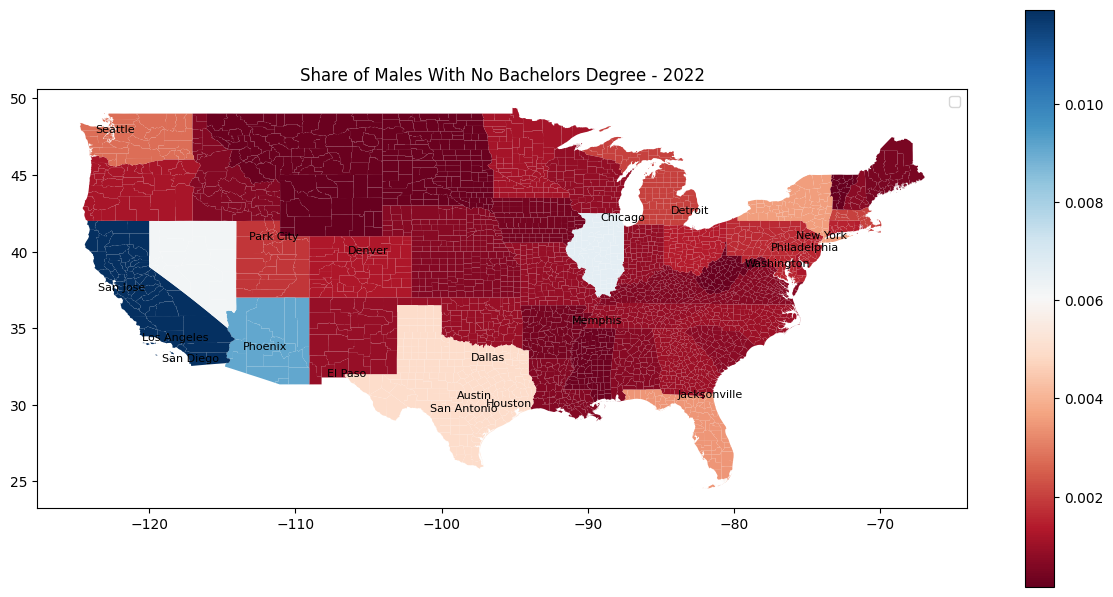

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('state_share_less_ba_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels

plt.legend()
plt.title("Share of Males With No Bachelors Degree - 2022")  # Add a title
plt.show()

<ipython-input-41-6205d792d289>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


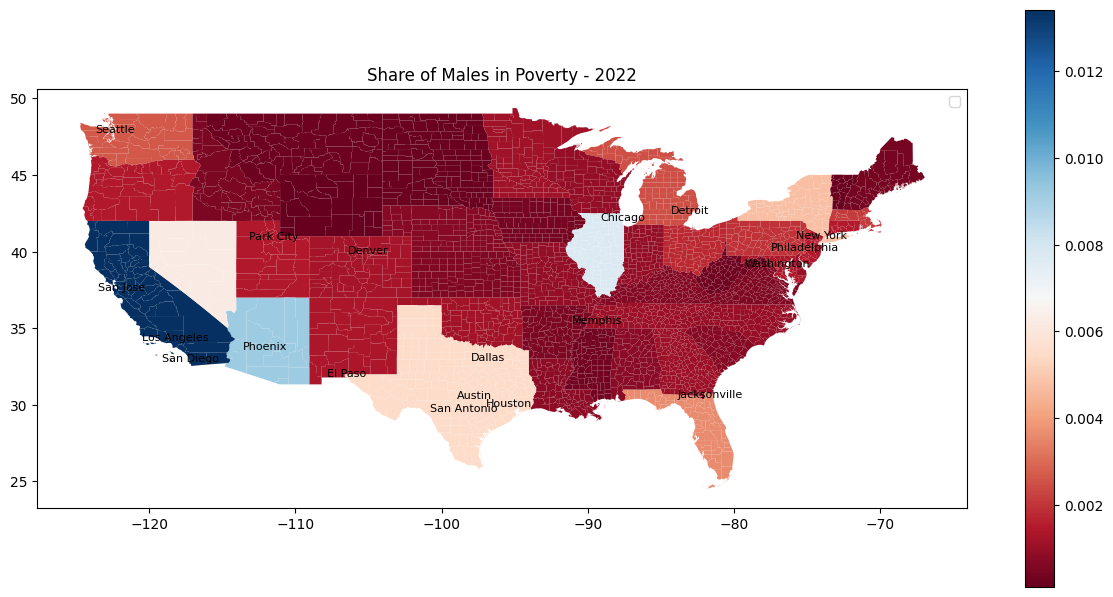

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('state_share_opm_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels

plt.legend()
plt.title("Share of Males in Poverty - 2022")  # Add a title
plt.show()

<ipython-input-42-f79310793a98>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


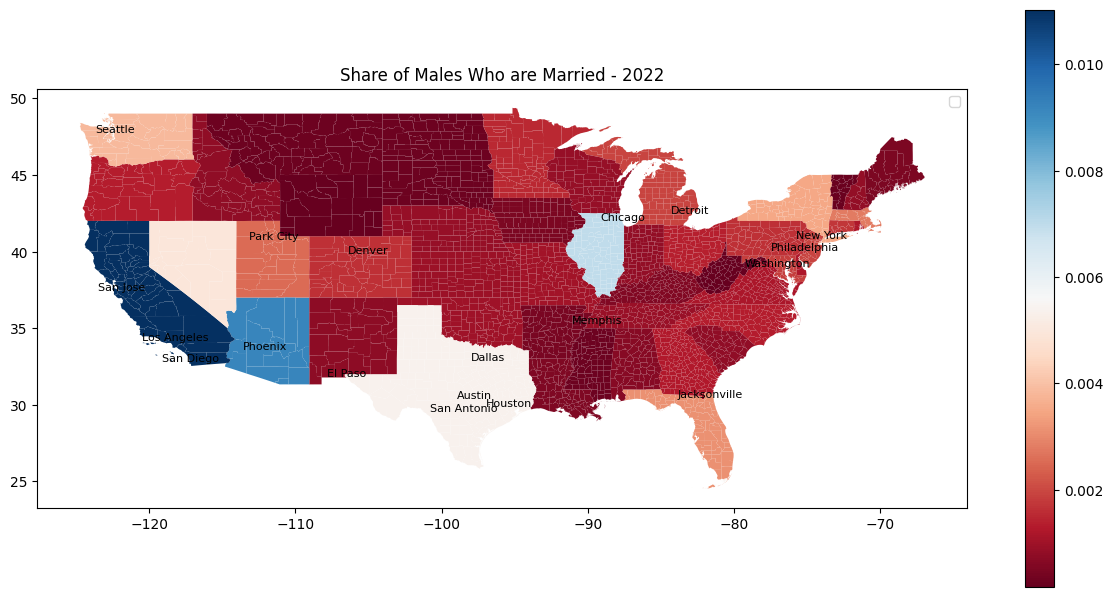

In [ ]:
males_state_agg_pivot[(males_state_agg_pivot['STATE_NAME'] != 'Alaska') & (males_state_agg_pivot['STATE_NAME'] != 'Hawaii')].plot('state_share_marriage_2022',
                                                                                                       figsize=(15,15),legend=True,
                                                                                                       cmap='RdBu',
                                                                                                       legend_kwds={'shrink': 0.5}) # Adjust shrink value as needed
add_city_labels(plt, city_locations) # Add city labels

plt.legend()
plt.title("Share of Males Who are Married - 2022")  # Add a title
plt.show()

#Descriptive Statistics

In [ ]:
vars = ['male_2564_less_ba_pct','opm_male_2554', 'male_marriage_rate_2554', 'perc_never_married']
acs_counties[ acs_counties['YEAR'] == '2022'][['male_2564_less_ba_pct','opm_male_2554', 'male_marriage_rate_2554', 'perc_never_married' ]].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
male_2564_less_ba_pct,3144.0,0.793915,0.108780,0.180262,0.747093,0.821017,0.868809,1.000000
opm_male_2554,3144.0,0.107536,0.057402,0.000000,0.068279,0.097670,0.133906,0.538265
male_marriage_rate_2554,3144.0,0.511147,0.111289,0.040000,0.455864,0.523384,0.578520,1.000000
perc_never_married,3144.0,0.318732,0.094309,0.000000,0.256537,0.310481,0.369130,0.920000


In [ ]:
acs_counties.columns

acs_counties[ acs_counties['YEAR'] == '2022'].iloc[:, 4:20].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
male_25_64_tot,3144.0,27420.625636,90477.104165,16.000000,2721.000000,6593.500000,17477.500000,2.773528e+06
male_2564_less_ba,3144.0,18325.658715,57439.828686,16.000000,2285.750000,5434.000000,13633.500000,1.838364e+06
male_2564_less_ba_pct,3144.0,0.793915,0.108780,0.180262,0.747093,0.821017,0.868809,1.000000e+00
pop_county_male_2554,3144.0,20303.420802,69979.315379,8.000000,1790.000000,4461.500000,12188.750000,2.158883e+06
pop_opm_county_male_2554,3144.0,1757.898537,6329.386523,0.000000,184.750000,486.500000,1231.500000,2.109490e+05
opm_male_2554,3144.0,0.107536,0.057402,0.000000,0.068279,0.097670,0.133906,5.382653e-01
pop_county_male_mar_2554,3144.0,10364.156489,32571.013663,1.000000,956.750000,2351.000000,6533.750000,8.858890e+05
pop_county_male_never_mar_2554,3144.0,7462.669847,29645.318003,0.000000,573.750000,1485.000000,4211.250000,1.022585e+06
pop_county_male_separated_2554,3144.0,384.089059,1342.403486,0.000000,28.000000,100.000000,276.250000,4.296400e+04
pop_county_male_other_2554,3144.0,660.700382,2898.817481,0.000000,39.000000,128.000000,371.250000,1.003730e+05


##Correlation Matrix fix

In [ ]:
vars = ['male_2564_less_ba_pct',
 'opm_male_2554',
 'male_marriage_rate_2554']

In [ ]:
# Correlation Matrix

corr_matrix = acs_counties[acs_counties['YEAR'] == '2022'][vars].corr()
corr_matrix


,male_2564_less_ba_pct,opm_male_2554,male_marriage_rate_2554
male_2564_less_ba_pct,1.000000,0.427415,-0.280777
opm_male_2554,0.427415,1.000000,-0.434407
male_marriage_rate_2554,-0.280777,-0.434407,1.000000


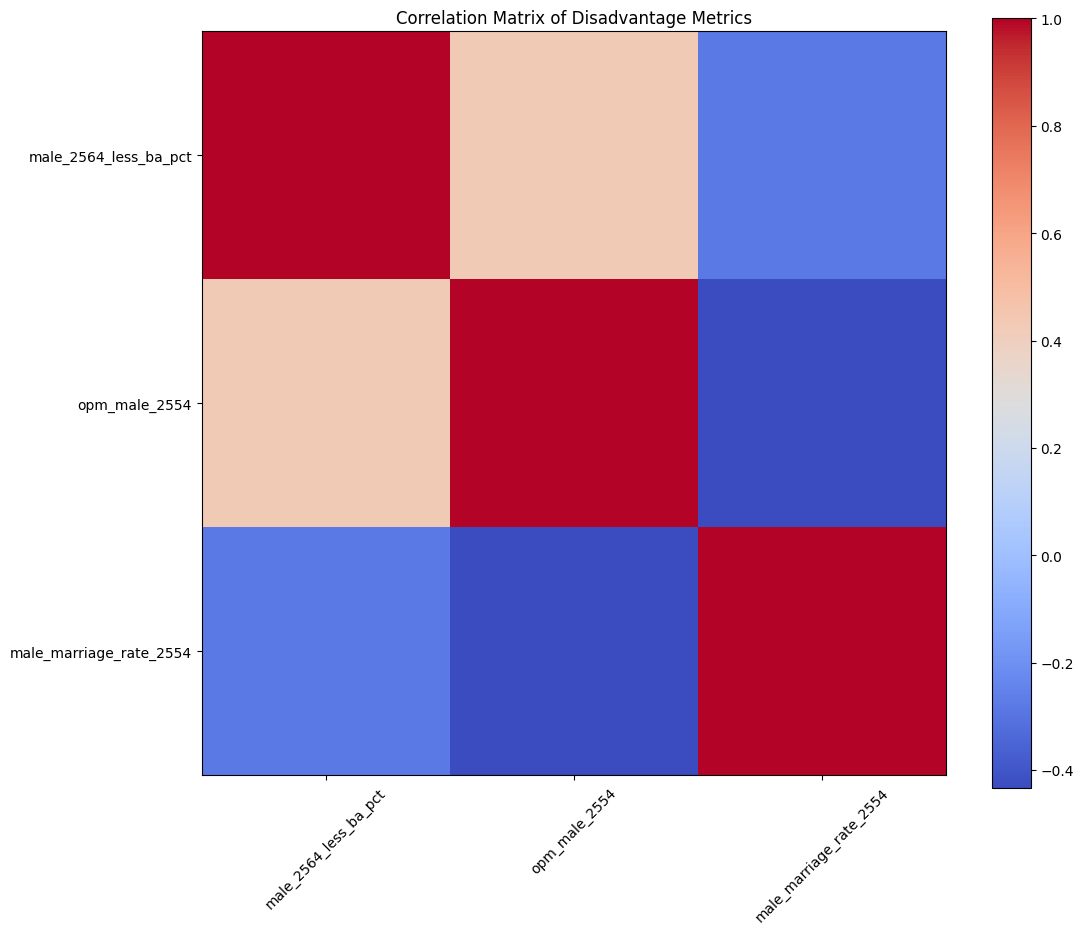

In [ ]:

# Visualization of the Correlation Matrix (optional)
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix of Disadvantage Metrics')
plt.show()

#Subgroup Analysis

##importing demographic data

In [ ]:
census_county_pop = pd.read_csv('census_county_pop.csv', dtype={'STATEFP': str, 'COUNTYFP': str,'COUNTY_FIPS':str})  # Replace with your file's name

census_county_pop = census_county_pop.drop(columns= 'Unnamed: 0')

census_county_pop.head()


,STATEFP,COUNTYFP,COUNTY_FIPS,COUNTY_TOTAL,MALES_COUNT,FEMALES_COUNT,ADULT_MALES,ADULT_FEMALES,GENDER_RATIO,MALE_PERC,...,OTHER,HISP_LAT,PERC_WHITE,PERC_BLACK,PERC_ASIAN,PERC_NAT_HAW,PERC_AM_IND,PERC_TWO_RACE,PERC_OTHER,PERC_HISP_LAT
0,01,001,01001,55639,27052,28587,16604,17402,0.954143,48.625930,...,374,1601,75.753058,19.532010,1.172864,0.044210,0.278986,2.543694,0.679383,2.874847
1,01,003,01003,218289,105889,112400,61415,65165,0.942454,48.510498,...,3398,9947,85.437100,8.772164,0.931584,0.004784,0.691396,2.597172,1.559201,4.546255
2,01,005,01005,25026,13156,11870,8494,6533,1.300168,52.561924,...,777,1110,46.298126,47.662731,0.492648,0.006329,0.353516,2.079825,3.122209,4.448054
3,01,007,01007,22374,12022,10352,7896,6218,1.269862,53.726294,...,9,600,76.574578,22.556351,0.245647,0.000000,0.051453,0.516519,0.041003,2.681157
4,01,009,01009,57755,28677,29078,17169,16832,1.020021,49.641299,...,1037,5362,93.977522,1.401160,0.396528,0.097569,0.093232,2.242036,1.799449,9.280597


##merging demographics to variables

In [ ]:
dem_merge = acs_counties[acs_counties['YEAR'] == '2022'].merge(census_county_pop, how='left', left_on='COUNTY_FIPS', right_on='COUNTY_FIPS')

In [ ]:
dem_merge.head()

,YEAR,STATE,COUNTY,COUNTY_FIPS,male_25_64_tot,male_2564_less_ba,male_2564_less_ba_pct,pop_county_male_2554,pop_opm_county_male_2554,opm_male_2554,...,OTHER,HISP_LAT,PERC_WHITE,PERC_BLACK,PERC_ASIAN,PERC_NAT_HAW,PERC_AM_IND,PERC_TWO_RACE,PERC_OTHER,PERC_HISP_LAT
0,2022,01,01001,01001,15250,10846,0.711213,11212.0,1116.0,0.099536,...,374.0,1601.0,75.753058,19.532010,1.172864,0.044210,0.278986,2.543694,0.679383,2.874847
1,2022,01,01003,01003,57268,39811,0.695170,40214.0,3071.0,0.076366,...,3398.0,9947.0,85.437100,8.772164,0.931584,0.004784,0.691396,2.597172,1.559201,4.546255
2,2022,01,01005,01005,7099,6603,0.930131,3367.0,441.0,0.130977,...,777.0,1110.0,46.298126,47.662731,0.492648,0.006329,0.353516,2.079825,3.122209,4.448054
3,2022,01,01007,01007,6864,6208,0.904429,4441.0,882.0,0.198604,...,9.0,600.0,76.574578,22.556351,0.245647,0.000000,0.051453,0.516519,0.041003,2.681157
4,2022,01,01009,01009,15334,13721,0.894809,10968.0,1163.0,0.106036,...,1037.0,5362.0,93.977522,1.401160,0.396528,0.097569,0.093232,2.242036,1.799449,9.280597


In [ ]:
dem_merge[['PERC_WHITE', 'PERC_BLACK', 'PERC_ASIAN', 'PERC_NAT_HAW', 'PERC_AM_IND',
       'PERC_TWO_RACE', 'PERC_OTHER', 'PERC_HISP_LAT']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PERC_WHITE,3135.0,81.757194,16.947555,3.3,74.609705,88.100000,94.098858,100.000000
PERC_BLACK,3135.0,9.025861,14.464058,0.0,0.675537,2.258131,10.092943,87.778014
PERC_ASIAN,3135.0,1.409382,2.859244,0.0,0.291387,0.637399,1.334905,42.596188
PERC_NAT_HAW,3135.0,0.117538,1.192611,0.0,0.000000,0.012496,0.072744,62.200000
PERC_AM_IND,3135.0,1.961522,7.735982,0.0,0.147444,0.332547,0.840382,94.539574
PERC_TWO_RACE,3135.0,3.516184,2.576965,0.0,1.896781,2.862491,4.370095,29.509474
PERC_OTHER,3135.0,2.211502,3.823300,0.0,0.395875,1.040984,2.503892,54.700000
PERC_HISP_LAT,3135.0,9.580137,13.923876,0.0,2.313918,4.372827,9.964486,98.908572


#race frequencies

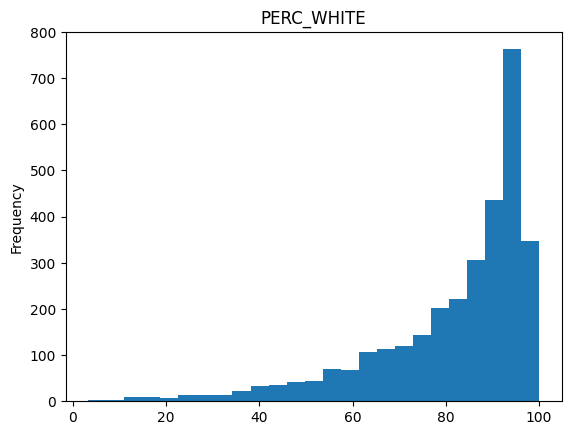

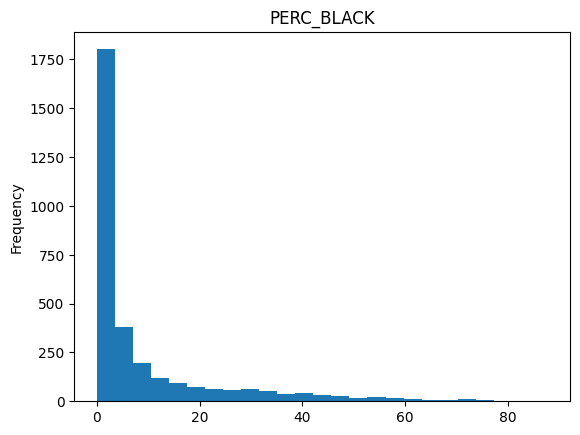

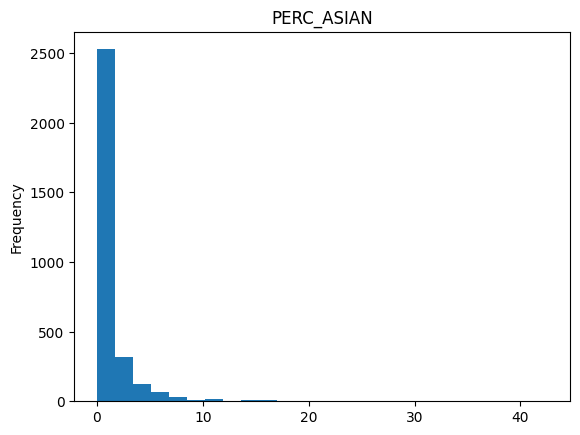

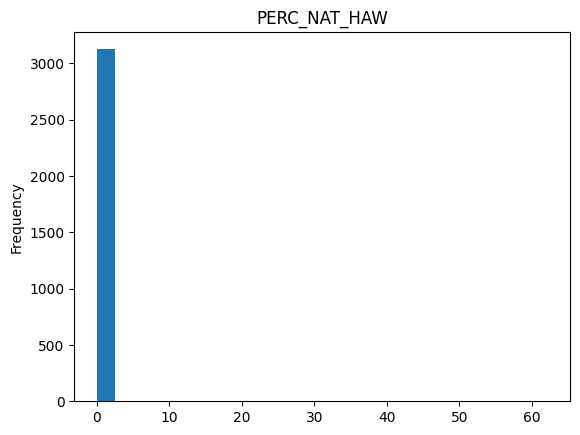

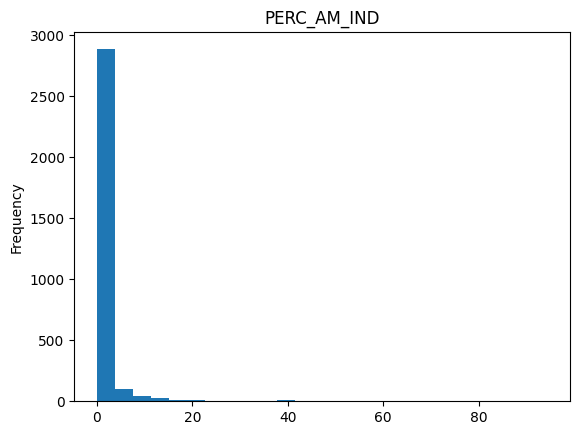

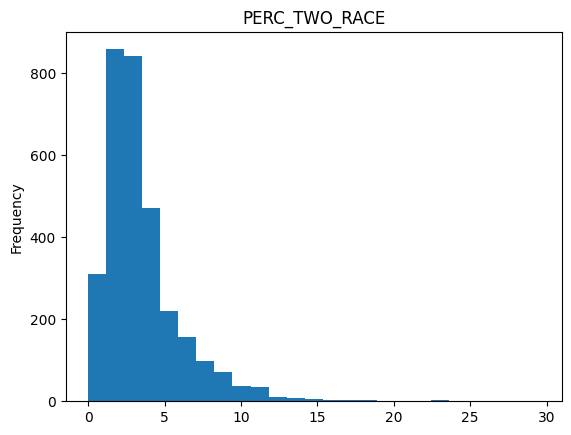

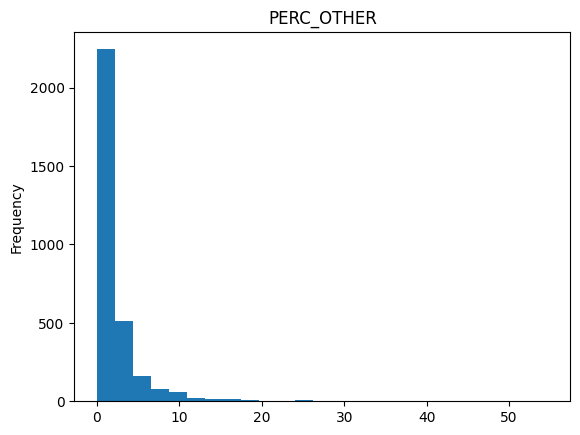

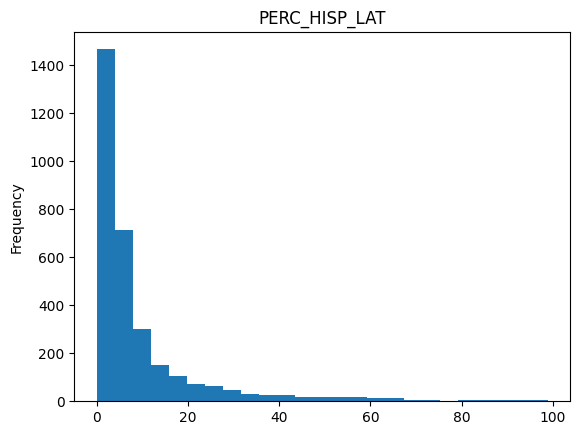

In [ ]:
races = ('PERC_WHITE', 'PERC_BLACK', 'PERC_ASIAN', 'PERC_NAT_HAW', 'PERC_AM_IND',
       'PERC_TWO_RACE', 'PERC_OTHER', 'PERC_HISP_LAT')

for i in races:
  dem_merge[i].plot.hist(bins = 25)
  title = i
  plt.title(title)
  plt.show()

In [ ]:
vars = ['male_2564_less_ba_pct','opm_male_2554', 'male_marriage_rate_2554', 'perc_never_married']

(array([0, 1, 2, 3]),
 [Text(0, 0, 'male_2564_less_ba_pct'),
  Text(1, 0, 'opm_male_2554'),
  Text(2, 0, 'male_marriage_rate_2554'),
  Text(3, 0, 'perc_never_married')])

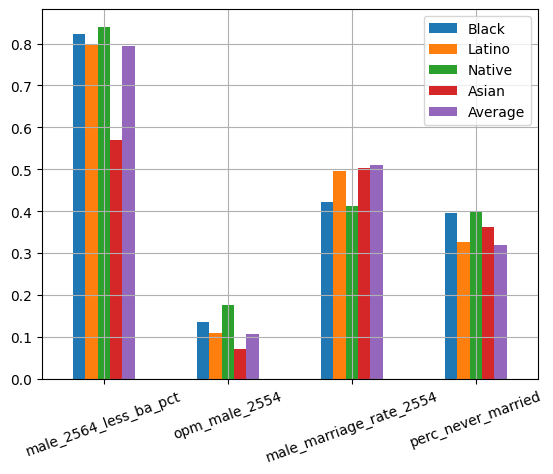

In [ ]:
marriage_sub = pd.DataFrame({'Black' : dem_merge[dem_merge['PERC_BLACK'] > 15][vars].mean(),
                           'Latino' : dem_merge[dem_merge['PERC_HISP_LAT'] > 15][vars].mean(),
                           'Native' : dem_merge[dem_merge['PERC_AM_IND'] > 5][vars].mean(),
                           'Asian' : dem_merge[dem_merge['PERC_ASIAN'] > 5][vars].mean(),
                           'Average' : dem_merge[vars].mean()})
#
marriage_sub2 = pd.DataFrame({'Black' : dem_merge[dem_merge['PERC_BLACK'] > 20][vars].mean(),
                           'Latino' : dem_merge[dem_merge['PERC_HISP_LAT'] > 20][vars].mean(),
                           'Native' : dem_merge[dem_merge['PERC_AM_IND'] > 10][vars].mean(),
                           'Asian' : dem_merge[dem_merge['PERC_ASIAN'] > 10][vars].mean(),
                           'Average' : dem_merge[vars].mean()})
#

marriage_sub2.plot.bar(grid=True,)
plt.xticks(rotation=20)

#full features join

beginning with dem_merge, which contains acs disadvantage metrics from 2022 and demographic data from 2020, I will join with economic, housing, and ADI tables

In [ ]:
economic_features = pd.read_csv('economic_features.csv', dtype={'STATEFP': str, 'COUNTYFP': str,'COUNTY_FIPS':str})
housing_features = pd.read_csv('housing_features.csv', dtype={'STATEFP': str, 'COUNTYFP': str,'COUNTY_FIPS':str})
ADI_ranks_county = pd.read_csv('ADI_ranks_county.csv', dtype={'STATEFP': str, 'COUNTYFP': str,'COUNTY_FIPS':str})



ADI_ranks_county = ADI_ranks_county[['STATEFP', 'COUNTYFP', 'COUNTY_FIPS',
       'ADI_NATRANK_2022', 'ADI_STATERNK_2022']]
ADI_ranks_county


,STATEFP,COUNTYFP,COUNTY_FIPS,ADI_NATRANK_2022,ADI_STATERNK_2022
0,01,001,01001,66.623043,4.330630
1,01,003,01003,50.503848,2.600217
2,01,005,01005,90.765204,8.113642
3,01,007,01007,84.257933,6.676790
4,01,009,01009,74.749815,5.039947
...,...,...,...,...,...
3226,72,145,72145,91.092345,5.875544
3227,72,147,72147,93.000000,6.000000
3228,72,149,72149,94.886901,7.597881
3229,72,151,72151,96.572869,8.436380


In [ ]:
economic_features.head()

,STATEFP,COUNTYFP,COUNTY_FIPS,County,Over_16,labor_force,employed,unemployed,armed_forces,unemployment_rate,...,male_median_earning,female_median_earning,per_capita_income,insured,private_health,public_health,uninsured,poverty_all_families,poverty_children_families,poverty_adults
0,01,069,01069,"Houston County, Alabama",83728.0,56.4,53.2,3.2,0.3,5.6,...,47684.0,34913.0,27794.0,88.6,61.9,40.2,11.4,12.6,20.9,16.5
1,01,023,01023,"Choctaw County, Alabama",10632.0,44.5,41.6,2.9,0.0,6.5,...,55430.0,27583.0,23292.0,89.9,59.3,47.6,10.1,18.4,32.9,19.0
2,01,005,01005,"Barbour County, Alabama",20407.0,45.8,42.7,3.2,0.0,6.9,...,41377.0,30181.0,20074.0,89.3,52.9,51.8,10.7,23.8,37.8,25.3
3,01,107,01107,"Pickens County, Alabama",16622.0,45.0,41.2,3.8,0.2,8.5,...,45139.0,34375.0,23476.0,90.6,59.1,48.7,9.4,18.7,34.6,22.8
4,01,033,01033,"Colbert County, Alabama",44790.0,54.8,52.6,2.2,0.1,4.0,...,44068.0,31877.0,25807.0,93.2,69.5,38.5,6.8,11.7,18.5,14.3


In [ ]:
housing_features.head()

,County_Name,State_Name,COUNTY_FIPS,STATEFP,COUNTYFP,County,HOUSING OCCUPANCY!!Total housing units!!Vacant housing units_Percent,HOUSING TENURE!!Occupied housing units!!Owner-occupied_Percent,HOUSING TENURE!!Occupied housing units!!Renter-occupied_Percent,VEHICLES AVAILABLE!!Occupied housing units!!No vehicles available_Percent,...,SELECTED MONTHLY OWNER COSTS AS A PERCENTAGE OF HOUSEHOLD INCOME (SMOCAPI)!!Housing unit without a mortgage (excluding units where SMOCAPI cannot be computed)!!30.0 to 34.9 percent_Percent,SELECTED MONTHLY OWNER COSTS AS A PERCENTAGE OF HOUSEHOLD INCOME (SMOCAPI)!!Housing unit without a mortgage (excluding units where SMOCAPI cannot be computed)!!35.0 percent or more_Percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!15.0 to 19.9 percent_Percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!20.0 to 24.9 percent_Percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!25.0 to 29.9 percent_Percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!30.0 to 34.9 percent_Percent,GROSS RENT AS A PERCENTAGE OF HOUSEHOLD INCOME (GRAPI)!!Occupied units paying rent (excluding units where GRAPI cannot be computed)!!35.0 percent or more_Percent,OCCUPANTS PER ROOM!!Occupied housing units!!1.51 or more_Estimate,SELECTED MONTHLY OWNER COSTS (SMOC)!!Housing units with a mortgage!!Median (dollars)_Estimate,Median_rent
0,Houston County,Alabama,01069,01,069,"Houston County, Alabama",15.8,65.5,34.5,6.2,...,1.6,7.0,13.7,12.5,9.9,8.0,36.5,137,1233.0,858.0
1,Choctaw County,Alabama,01023,01,023,"Choctaw County, Alabama",26.8,82.0,18.0,5.7,...,2.7,9.6,14.9,8.9,7.5,8.0,37.8,0,1077.0,616.0
2,Barbour County,Alabama,01005,01,005,"Barbour County, Alabama",22.8,65.0,35.0,11.7,...,3.0,13.5,16.3,18.1,9.4,6.4,35.9,62,1134.0,627.0
3,Pickens County,Alabama,01107,01,107,"Pickens County, Alabama",18.7,74.2,25.8,7.8,...,3.0,9.1,7.8,15.3,12.3,11.3,35.5,42,1101.0,578.0
4,Colbert County,Alabama,01033,01,033,"Colbert County, Alabama",16.0,71.0,29.0,4.7,...,2.8,9.9,13.5,10.1,13.6,9.1,37.0,57,1179.0,810.0


In [ ]:
ADI_ranks_county.head()

,STATEFP,COUNTYFP,COUNTY_FIPS,ADI_NATRANK_2022,ADI_STATERNK_2022
0,01,001,01001,66.623043,4.330630
1,01,003,01003,50.503848,2.600217
2,01,005,01005,90.765204,8.113642
3,01,007,01007,84.257933,6.676790
4,01,009,01009,74.749815,5.039947


In [ ]:
column_to_move = dem_merge.pop("STATEFP")
dem_merge.insert(4, "STATEFP", column_to_move)
column_to_move = dem_merge.pop("COUNTYFP")
dem_merge.insert(5, "COUNTYFP", column_to_move)

In [ ]:
dem_percentages = dem_merge.drop(columns=['COUNTY_TOTAL',
       'MALES_COUNT', 'FEMALES_COUNT', 'ADULT_MALES', 'ADULT_FEMALES','WHITE', 'BLACK', 'ASIAN',
       'NAT_HAW', 'AM_IND', 'TWO_RACE', 'OTHER', 'HISP_LAT',])
dem_percentages.head()

,YEAR,STATE,COUNTY,COUNTY_FIPS,STATEFP,COUNTYFP,male_25_64_tot,male_2564_less_ba,male_2564_less_ba_pct,pop_county_male_2554,...,MALE_PERC,FEMALE_PERC,PERC_WHITE,PERC_BLACK,PERC_ASIAN,PERC_NAT_HAW,PERC_AM_IND,PERC_TWO_RACE,PERC_OTHER,PERC_HISP_LAT
0,2022,01,01001,01001,01,001,15250,10846,0.711213,11212.0,...,48.625930,51.374070,75.753058,19.532010,1.172864,0.044210,0.278986,2.543694,0.679383,2.874847
1,2022,01,01003,01003,01,003,57268,39811,0.695170,40214.0,...,48.510498,51.489502,85.437100,8.772164,0.931584,0.004784,0.691396,2.597172,1.559201,4.546255
2,2022,01,01005,01005,01,005,7099,6603,0.930131,3367.0,...,52.561924,47.438076,46.298126,47.662731,0.492648,0.006329,0.353516,2.079825,3.122209,4.448054
3,2022,01,01007,01007,01,007,6864,6208,0.904429,4441.0,...,53.726294,46.273706,76.574578,22.556351,0.245647,0.000000,0.051453,0.516519,0.041003,2.681157
4,2022,01,01009,01009,01,009,15334,13721,0.894809,10968.0,...,49.641299,50.358701,93.977522,1.401160,0.396528,0.097569,0.093232,2.242036,1.799449,9.280597


In [ ]:
full_feature = dem_percentages.merge(economic_features,
                               how='left', left_on=['STATEFP','COUNTYFP','COUNTY_FIPS'],
                               right_on=['STATEFP','COUNTYFP','COUNTY_FIPS']).drop(columns=['County', 'Over_16'])


full_feature = full_feature.merge(housing_features,
                                  how='left', left_on=['STATEFP','COUNTYFP','COUNTY_FIPS'],
                                  right_on=['STATEFP','COUNTYFP','COUNTY_FIPS']). drop(columns=['County_Name', 'State_Name',])

full_feature = full_feature.merge(ADI_ranks_county, how='left', left_on=['STATEFP','COUNTYFP','COUNTY_FIPS'],
                                  right_on=['STATEFP','COUNTYFP','COUNTY_FIPS'])

column_to_move = full_feature.pop("County")
full_feature.insert(6, "County", column_to_move)
print(full_feature.shape)



(3144, 124)


In [ ]:
full_feature.to_csv('full_feature.csv', index=False)  # Set index=False to avoid saving the DataFrame index

#clustering

In [ ]:
len(full_feature.columns.tolist())
cluster_features = full_feature.columns.tolist()[21:128]
len(cluster_features)

103

In [ ]:
full_feature.columns.tolist()[21:128]

['GENDER_RATIO',
 'MALE_PERC',
 'FEMALE_PERC',
 'PERC_WHITE',
 'PERC_BLACK',
 'PERC_ASIAN',
 'PERC_NAT_HAW',
 'PERC_AM_IND',
 'PERC_TWO_RACE',
 'PERC_OTHER',
 'PERC_HISP_LAT',
 'labor_force',
 'employed',
 'unemployed',
 'armed_forces',
 'unemployment_rate',
 'young_children_two_income',
 'older_children_two_income',
 'commute_drive_alone',
 'commute_carpool',
 'commute_public',
 'commute_walked',
 'commute_other',
 'commute_wfh',
 'mean_travel_time',
 'occ_man_bus_sci_arts',
 'occ_service',
 'occ_sales_office',
 'occ_nat_con_maint',
 'occ_prod_trans_mater',
 'ind_ag_for_fish',
 'ind_construction',
 'ind_manufacturing',
 'ind_wholesale',
 'ind_retail',
 'ind_trans_warehouse_utilities',
 'ind_information',
 'ind_finance_ins_realestate',
 'ind_prof_sci_man_admin',
 'ind_ed_health_social',
 'ind_hospitality',
 'ind_other',
 'ind_public_admin',
 'class_priv_salary',
 'class_government',
 'class_self_employed',
 'class_unpaid_family',
 'median_household_income',
 'mean_household_income',
 '

In [ ]:
cluster_features = full_feature.columns.tolist()[21:128]
cluster_features

['GENDER_RATIO',
 'MALE_PERC',
 'FEMALE_PERC',
 'PERC_WHITE',
 'PERC_BLACK',
 'PERC_ASIAN',
 'PERC_NAT_HAW',
 'PERC_AM_IND',
 'PERC_TWO_RACE',
 'PERC_OTHER',
 'PERC_HISP_LAT',
 'labor_force',
 'employed',
 'unemployed',
 'armed_forces',
 'unemployment_rate',
 'young_children_two_income',
 'older_children_two_income',
 'commute_drive_alone',
 'commute_carpool',
 'commute_public',
 'commute_walked',
 'commute_other',
 'commute_wfh',
 'mean_travel_time',
 'occ_man_bus_sci_arts',
 'occ_service',
 'occ_sales_office',
 'occ_nat_con_maint',
 'occ_prod_trans_mater',
 'ind_ag_for_fish',
 'ind_construction',
 'ind_manufacturing',
 'ind_wholesale',
 'ind_retail',
 'ind_trans_warehouse_utilities',
 'ind_information',
 'ind_finance_ins_realestate',
 'ind_prof_sci_man_admin',
 'ind_ed_health_social',
 'ind_hospitality',
 'ind_other',
 'ind_public_admin',
 'class_priv_salary',
 'class_government',
 'class_self_employed',
 'class_unpaid_family',
 'median_household_income',
 'mean_household_income',
 '

In [ ]:

from sklearn.cluster import KMeans
import numpy as np

# Assuming 'man_counties' DataFrame is already loaded and preprocessed as in the provided code.

# Select features for clustering (replace with your desired features)



cluster_features = full_feature.columns.tolist()[21:128] # Example features
X = full_feature[cluster_features].dropna()  # Remove rows with missing values in selected features

In [ ]:
X.shape

(2932, 103)

In [ ]:
# Determine optimal number of clusters (e.g., using the Elbow method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

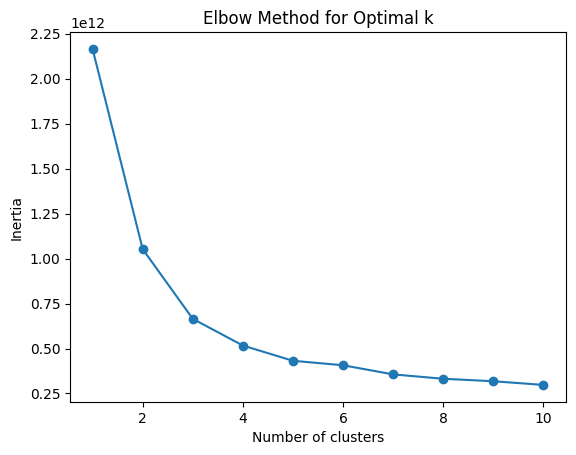

In [ ]:
# Plot inertia to find the elbow point
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()


In [ ]:

# Based on the elbow method, choose the optimal number of clusters (e.g., k=3)
optimal_k = 4  # Replace with the value you determined from the elbow method plot

# Perform KMeans clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
full_feature['cluster'] = np.nan # Initialize a new column for cluster assignments
full_feature.loc[X.index, 'cluster'] = kmeans.fit_predict(X)



#Cluster Map

In [ ]:
full_feature_geo = counties.merge(full_feature, how='left', left_on=['STATEFP',	'COUNTYFP',	'COUNTY_FIPS'], right_on=['STATEFP',	'COUNTYFP',	'COUNTY_FIPS'])

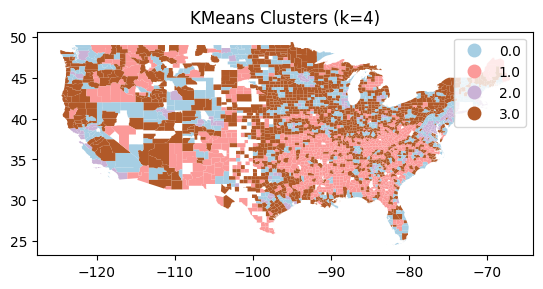

In [ ]:
# Analyze and visualize the clusters
# Example: plot the clusters on a map colored by cluster assignment
full_feature_geo[(full_feature_geo['STATE'] != '02')&(full_feature_geo['STATE'] != '15')].plot(column='cluster',
                                                                                               categorical=True,
                                                                                               legend=True,
                                                                                               cmap='Paired')  # Adjust cmap as desired
plt.title(f'KMeans Clusters (k={optimal_k})')
plt.show()



#Cluster Breakdown

In [ ]:
dis_cluster = full_feature.groupby('cluster')[vars].mean()
dis_cluster

KeyError: 'cluster'

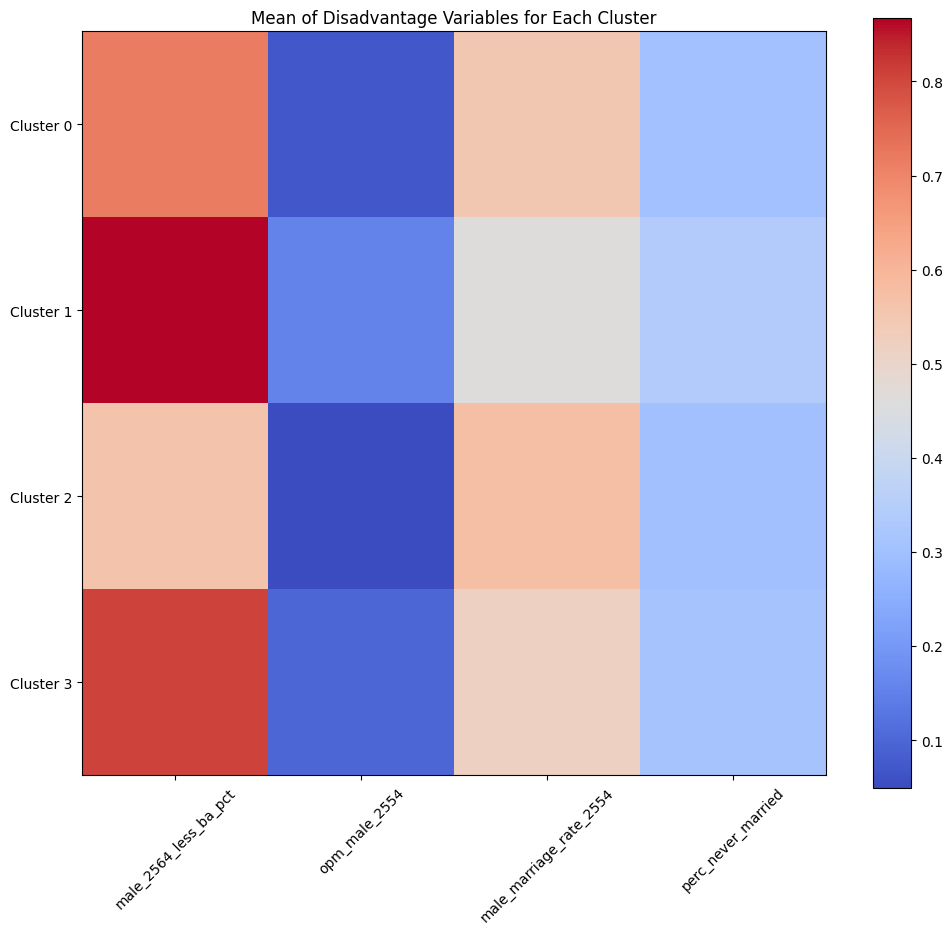

In [ ]:
plt.figure(figsize=(12, 10))
plt.imshow(dis_cluster, cmap='coolwarm', interpolation='nearest', label = True)
plt.colorbar()
plt.xticks(range(len(dis_cluster.columns)), dis_cluster.columns, rotation=45)
plt.yticks(range(0,4), ['Cluster 0','Cluster 1','Cluster 2','Cluster 3'])
plt.title('Mean of Disadvantage Variables for Each Cluster')
plt.show()

Text(0.5, 1.0, 'Racial Makeup of Each Cluster')

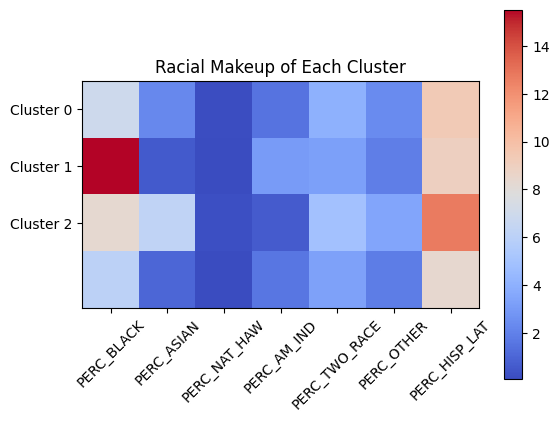

In [ ]:
races = ['PERC_BLACK', 'PERC_ASIAN', 'PERC_NAT_HAW', 'PERC_AM_IND',
       'PERC_TWO_RACE', 'PERC_OTHER', 'PERC_HISP_LAT']

race_cluster = full_feature.groupby('cluster')[races].mean()

plt.imshow(race_cluster, cmap='coolwarm', interpolation='nearest', label = True)
plt.colorbar()
plt.xticks(range(len(race_cluster.columns)), race_cluster.columns, rotation=45)
plt.yticks(range(0,3), ['Cluster 0','Cluster 1','Cluster 2'])
plt.title('Racial Makeup of Each Cluster')


#random forest 1

##less ba rf

In [ ]:
# prompt: random forest to predict male_marriage_rate_2554

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare the data
features = cluster_features
target = 'male_2564_less_ba_pct'

X = full_feature[features].dropna()
y = full_feature.loc[X.index, target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Feature Importance
feature_importances = rf_model.feature_importances_


Mean Squared Error: 0.001494220434788583
R-squared: 0.866684517044375


In [ ]:
less_ba_feature_importance = pd.DataFrame({"Feature" : features, "Importance": feature_importances}).sort_values(by='Importance', ascending=False)
less_ba_feature_importance.head(10)

,Feature,Importance
25,occ_man_bus_sci_arts,0.615678
60,per_capita_income,0.053350
28,occ_nat_con_maint,0.034022
38,ind_prof_sci_man_admin,0.032192
101,ADI_NATRANK_2022,0.029829
5,PERC_ASIAN,0.020173
100,Median_rent,0.020150
30,ind_ag_for_fish,0.013484
12,employed,0.011639
48,mean_household_income,0.010413


##opm rf

In [ ]:
# prompt: random forest to predict male_marriage_rate_2554

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare the data
features = cluster_features
target = 'opm_male_2554'

X = full_feature[features].dropna()
y = full_feature.loc[X.index, target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Feature Importance
feature_importances2 = rf_model.feature_importances_


Mean Squared Error: 0.0009681419370227364
R-squared: 0.7188240591331693


In [ ]:
poverty_feature_importance = pd.DataFrame({"Feature" : features, "Importance": feature_importances2}).sort_values(by='Importance', ascending=False)
poverty_feature_importance.head(10)

,Feature,Importance
67,poverty_adults,0.548338
63,public_health,0.029184
62,private_health,0.027241
65,poverty_all_families,0.027070
66,poverty_children_families,0.014492
48,mean_household_income,0.011030
47,median_household_income,0.010874
12,employed,0.010369
43,class_priv_salary,0.009219
57,perc_snap,0.008764


##marriage rf

In [ ]:
# prompt: random forest to predict male_marriage_rate_2554

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Prepare the data
features = cluster_features
target = 'male_marriage_rate_2554'

X = full_feature[features].dropna()
y = full_feature.loc[X.index, target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # You can adjust n_estimators
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Feature Importance
feature_importances3 = rf_model.feature_importances_


Mean Squared Error: 0.0030607352255126157
R-squared: 0.7040926318510498


In [ ]:
marriage_feature_importance = pd.DataFrame({"Feature" : features, "Importance": feature_importances3}).sort_values(by='Importance', ascending=False)
marriage_feature_importance.head(10)

,Feature,Importance
0,GENDER_RATIO,0.187177
72,VEHICLES AVAILABLE!!Occupied housing units!!1 ...,0.167229
12,employed,0.100185
3,PERC_WHITE,0.098638
63,public_health,0.035709
57,perc_snap,0.020120
1,MALE_PERC,0.019319
2,FEMALE_PERC,0.015655
71,VEHICLES AVAILABLE!!Occupied housing units!!No...,0.015141
11,labor_force,0.014305


#RF Graphs

In [ ]:
less_ba_feature_importance.head()['Feature'].tolist()


['occ_man_bus_sci_arts',
 'per_capita_income',
 'occ_nat_con_maint',
 'ind_prof_sci_man_admin',
 'ADI_NATRANK_2022']

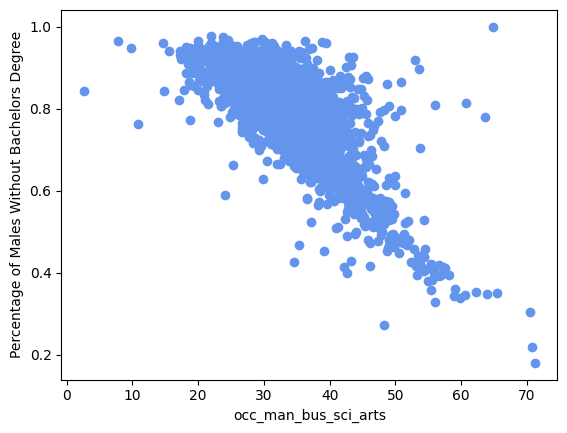

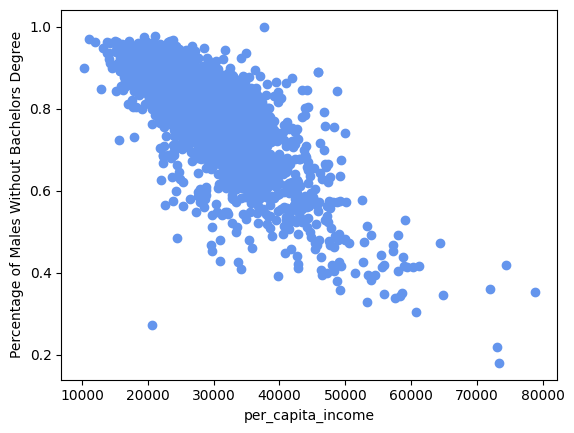

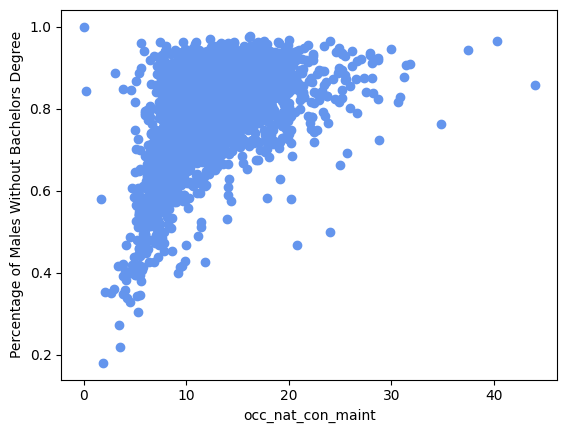

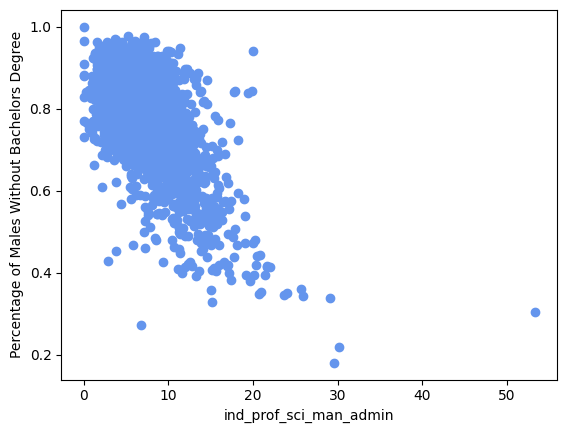

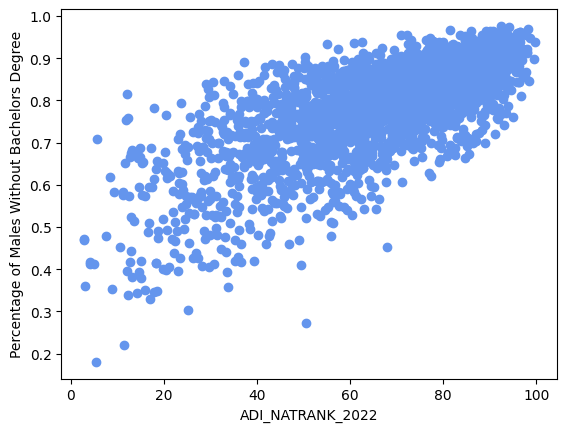

In [ ]:
for i in less_ba_feature_importance.head()['Feature'].tolist():
  plt.scatter( full_feature[i], full_feature['male_2564_less_ba_pct'], color = 'cornflowerblue')
  plt.xlabel(i)
  plt.ylabel('Percentage of Males Without Bachelors Degree')
  plt.show()

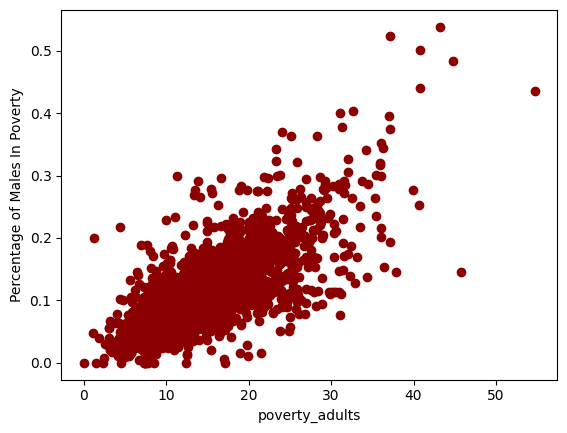

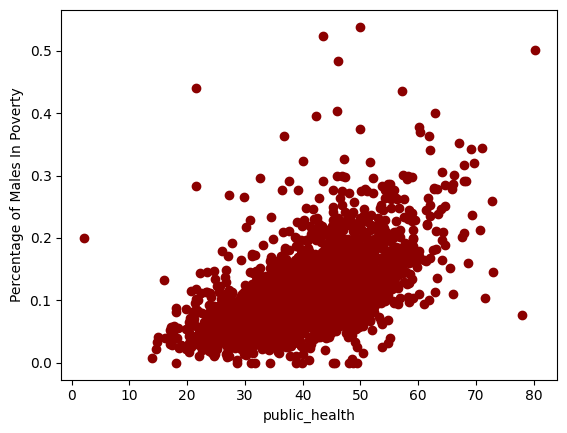

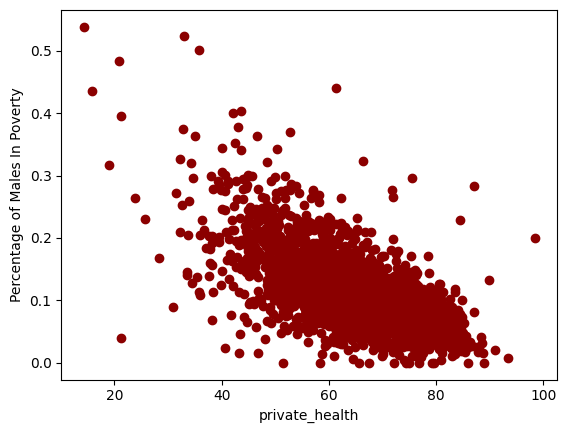

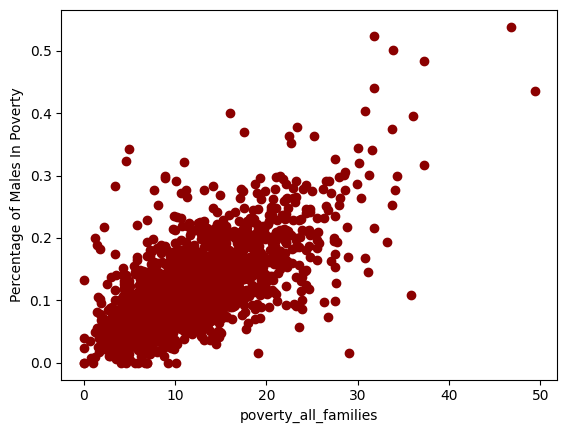

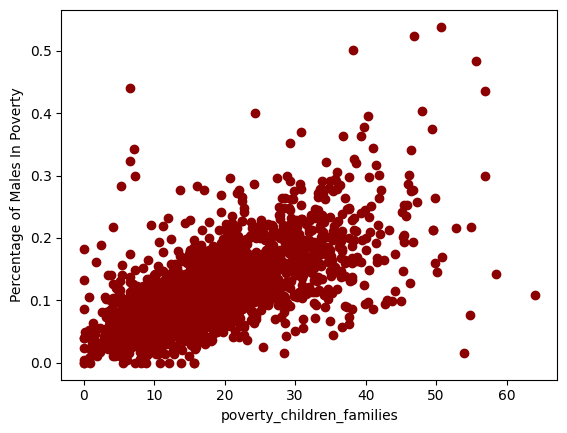

In [ ]:
for i in poverty_feature_importance.head()['Feature'].tolist():
  plt.scatter( full_feature[i], full_feature['opm_male_2554'], color = 'darkred')
  plt.xlabel(i)
  plt.ylabel('Percentage of Males In Poverty')
  plt.show()

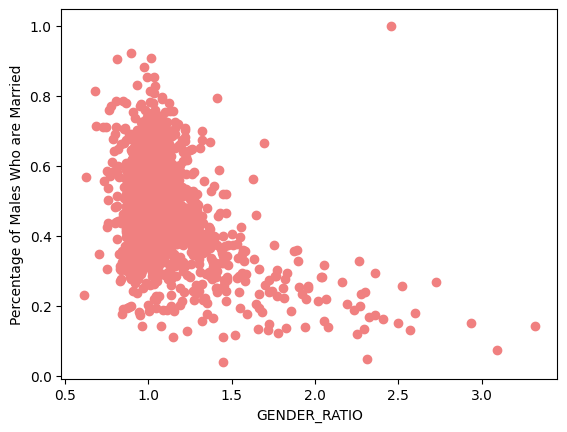

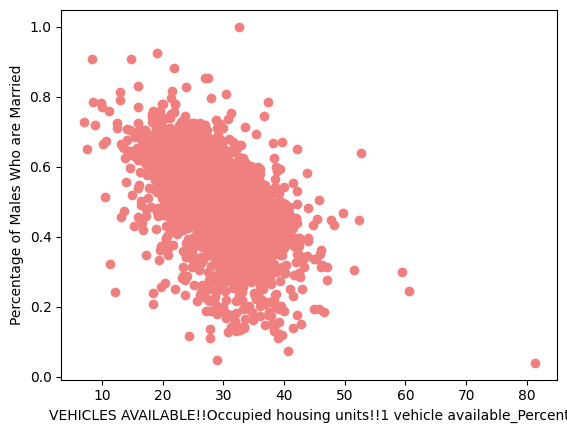

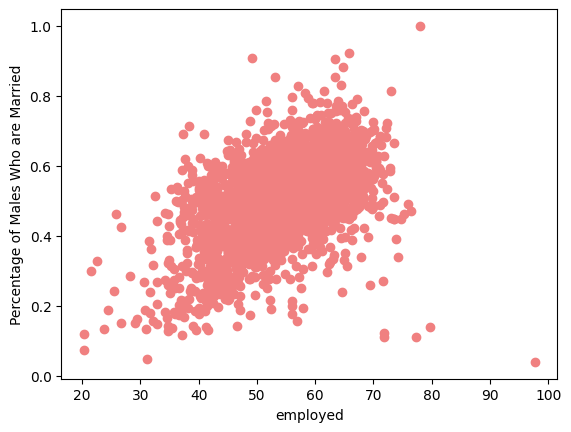

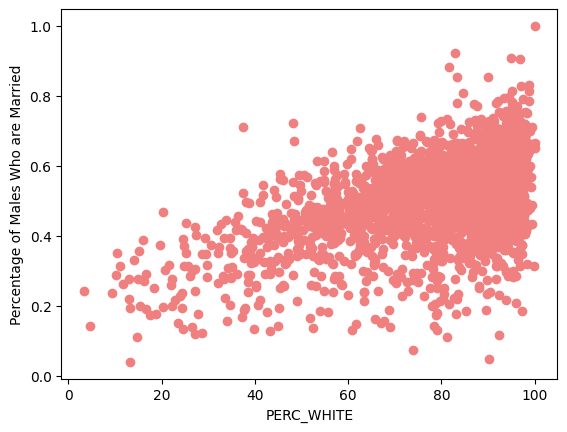

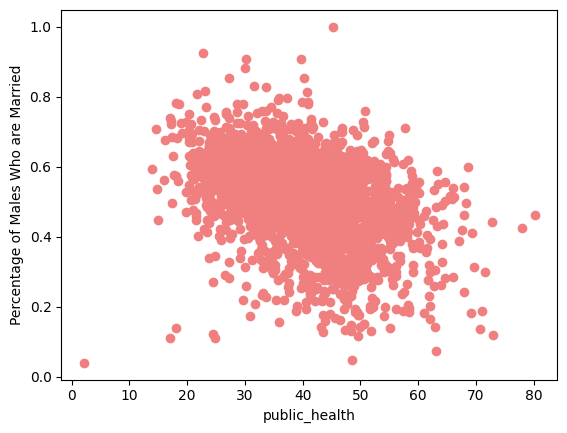

In [ ]:
for i in marriage_feature_importance.head()['Feature'].tolist():
  plt.scatter( full_feature[i], full_feature['male_marriage_rate_2554'], color = 'lightcoral')
  plt.xlabel(i)
  plt.ylabel('Percentage of Males Who are Married')
  plt.show()